In [15]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD PROJECT DATA
# ============================================================

raw_df = pd.read_csv("../data/raw/TEJAS_RAW_DATA.csv")

preprocessed_df = pd.read_csv(
    "../data/processed/TEJAS_PREPROCESSED.csv"
)

route_df = pd.read_csv("../data/raw/ROUTE.csv")

# ============================================================
# BASIC CHECK
# ============================================================

print("RAW DATASET")
print("Shape:", raw_df.shape)

print("\nPREPROCESSED DATASET")
print("Shape:", preprocessed_df.shape)

print("\nROUTE DATASET")
print("Shape:", route_df.shape)

print("\nRAW YEARS:")
print(sorted(raw_df["Year"].unique()))

print("\nRAW DEPOTS:")
print(raw_df["Depot ID"].nunique())

print("\nROUTE DEPOTS:")
print(route_df["Depot_ID"].nunique())

RAW DATASET
Shape: (5520, 20)

PREPROCESSED DATASET
Shape: (5520, 116)

ROUTE DATASET
Shape: (92, 9)

RAW YEARS:
[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

RAW DEPOTS:
92

ROUTE DEPOTS:
92


In [16]:
# ============================================================
# CELL 2 — Inspect Preprocessed Dataset
# ============================================================

print("PREPROCESSED SHAPE:", preprocessed_df.shape)

print("\nPREPROCESSED COLUMNS:")
for i, col in enumerate(preprocessed_df.columns, 1):
    print(i, ":", col)

print("\nMISSING VALUES:")
print(preprocessed_df.isna().sum().sum())

print("\nOLD TARGET CHECK:")
print(
    "EV Suitability Score" in preprocessed_df.columns
)

PREPROCESSED SHAPE: (5520, 116)

PREPROCESSED COLUMNS:
1 : Buses Allocated
2 : Schedules Allocated
3 : Effective KM
4 : Passengers
5 : Estimated Diesel Litres
6 : Estimated CO2 (Tonnes)
7 : Estimated EV Energy (MWh)
8 : Potential EV OPEX Saving (INR)
9 : Year
10 : Month_Number
11 : Passengers_per_Bus
12 : Depot ID_KSRTC-002
13 : Depot ID_KSRTC-003
14 : Depot ID_KSRTC-004
15 : Depot ID_KSRTC-005
16 : Depot ID_KSRTC-006
17 : Depot ID_KSRTC-007
18 : Depot ID_KSRTC-008
19 : Depot ID_KSRTC-009
20 : Depot ID_KSRTC-010
21 : Depot ID_KSRTC-011
22 : Depot ID_KSRTC-012
23 : Depot ID_KSRTC-013
24 : Depot ID_KSRTC-014
25 : Depot ID_KSRTC-015
26 : Depot ID_KSRTC-016
27 : Depot ID_KSRTC-017
28 : Depot ID_KSRTC-018
29 : Depot ID_KSRTC-019
30 : Depot ID_KSRTC-020
31 : Depot ID_KSRTC-021
32 : Depot ID_KSRTC-022
33 : Depot ID_KSRTC-023
34 : Depot ID_KSRTC-024
35 : Depot ID_KSRTC-025
36 : Depot ID_KSRTC-026
37 : Depot ID_KSRTC-027
38 : Depot ID_KSRTC-028
39 : Depot ID_KSRTC-029
40 : Depot ID_KSRTC-030
41

In [17]:
# ============================================================
# CELL 3 — Select ML Features
# ============================================================

# Features we will consider for the new EV transition model
candidate_features = [
    "Buses Allocated",
    "Schedules Allocated",
    "Effective KM",
    "Passengers",
    "Estimated Diesel Litres",
    "Estimated CO2 (Tonnes)",
    "Estimated EV Energy (MWh)",
    "Potential EV OPEX Saving (INR)",
    "Passengers_per_Bus",
    "Year",
    "Month_Number"
]

print("CANDIDATE ML FEATURES")
print("---------------------")

for col in candidate_features:
    print(col, "->", col in preprocessed_df.columns)

print("\nOLD TARGET:")
print("EV Suitability Score")

print("\nOLD TARGET WILL NOT BE USED AS A FEATURE.")

CANDIDATE ML FEATURES
---------------------
Buses Allocated -> True
Schedules Allocated -> True
Effective KM -> True
Passengers -> True
Estimated Diesel Litres -> True
Estimated CO2 (Tonnes) -> True
Estimated EV Energy (MWh) -> True
Potential EV OPEX Saving (INR) -> True
Passengers_per_Bus -> True
Year -> True
Month_Number -> True

OLD TARGET:
EV Suitability Score

OLD TARGET WILL NOT BE USED AS A FEATURE.


In [19]:
# ============================================================
# CELL 4 — Create Target Dataset
# ============================================================

# Start from RAW data for target construction
# Start from PREPROCESSED data later for ML features

data = raw_df.copy()

# Add terrain information
data = data.merge(
    route_df[["Depot_ID", "Terrain_Score"]],
    left_on="Depot ID",
    right_on="Depot_ID",
    how="left"
)

# Remove old suitability score
data = data.drop(columns=["EV Suitability Score"])

print("Target construction dataset:", data.shape)
print("Terrain matched:", data["Terrain_Score"].notna().sum(), "/", len(data))

Target construction dataset: (5520, 21)
Terrain matched: 5520 / 5520


In [20]:
# ============================================================
# CELL 5 — Create New EV Transition Priority Score
# ============================================================

# Normalize a value between 0 and 1
def minmax(x):
    if x.max() == x.min():
        return 0.5
    return (x - x.min()) / (x.max() - x.min())

# Economic benefit
data["Economic_Score"] = minmax(
    data["Potential EV OPEX Saving (INR)"]
)

# Environmental benefit
data["Environmental_Score"] = minmax(
    data["Estimated CO2 (Tonnes)"]
)

# Operational suitability
data["KM_Score"] = minmax(
    data["Effective KM"]
)

data["Passenger_Score"] = minmax(
    data["Passengers"]
)

data["Operational_Score"] = (
    0.5 * data["KM_Score"] +
    0.5 * data["Passenger_Score"]
)

# Technical feasibility
# Higher range margin = better feasibility
EV_RANGE = 200

data["Technical_Score"] = (
    1 -
    (data["Effective KM"] /
     data["Buses Allocated"] /
     EV_RANGE)
).clip(0, 1)

# Final transition score
data["EV_Transition_Score"] = (
    0.30 * data["Economic_Score"] +
    0.25 * data["Environmental_Score"] +
    0.20 * data["Operational_Score"] +
    0.15 * data["Technical_Score"] +
    0.10 * data["Terrain_Score"]
)

print("NEW TARGET CREATED")
print("------------------")

print(
    data["EV_Transition_Score"].describe().round(4)
)

NEW TARGET CREATED
------------------
count    5520.0000
mean        0.3314
std         0.1300
min         0.0413
25%         0.2378
50%         0.3221
75%         0.4094
max         0.8308
Name: EV_Transition_Score, dtype: float64


In [21]:
# ============================================================
# CELL 5 — Annual Depot EV Transition Target
# ============================================================

# Aggregate the raw data to yearly depot level
annual = (
    data[data["Year"].between(2022, 2025)]
    .groupby(
        ["Year", "Depot ID"],
        as_index=False
    )
    .agg({
        "Effective KM": "sum",
        "Passengers": "sum",
        "Buses Allocated": "mean",
        "Schedules Allocated": "mean",
        "Estimated CO2 (Tonnes)": "sum",
        "Estimated EV Energy (MWh)": "sum",
        "Potential EV OPEX Saving (INR)": "sum",
        "Terrain_Score": "first"
    })
)

# Operational measure
annual["Passengers_per_Bus"] = (
    annual["Passengers"] /
    annual["Buses Allocated"]
)

# Economic measure
annual["Saving_per_Bus"] = (
    annual["Potential EV OPEX Saving (INR)"] /
    annual["Buses Allocated"]
)

# Normalize within each year
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

annual["Economic_Score"] = (
    annual.groupby("Year")["Saving_per_Bus"]
    .transform(normalize)
)

annual["Environmental_Score"] = (
    annual.groupby("Year")["Estimated CO2 (Tonnes)"]
    .transform(normalize)
)

annual["Operational_Score"] = (
    0.5 * annual.groupby("Year")["Effective KM"].transform(normalize)
    +
    0.5 * annual.groupby("Year")["Passengers"].transform(normalize)
)

# Technical feasibility
annual["Technical_Score"] = (
    1 -
    (
        annual["Effective KM"] /
        annual["Buses Allocated"] /
        365
    ) / 200
).clip(0, 1)

# Final target score
annual["EV_Transition_Score"] = (
    0.30 * annual["Economic_Score"] +
    0.25 * annual["Environmental_Score"] +
    0.20 * annual["Operational_Score"] +
    0.15 * annual["Technical_Score"] +
    0.10 * annual["Terrain_Score"]
)

print("ANNUAL TARGET DATASET")
print("---------------------")
print("Shape:", annual.shape)
print("Depots:", annual["Depot ID"].nunique())
print("Years:", sorted(annual["Year"].unique()))

print("\nTarget score:")
print(
    annual["EV_Transition_Score"]
    .describe()
    .round(4)
)

ANNUAL TARGET DATASET
---------------------
Shape: (368, 17)
Depots: 92
Years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Target score:
count    368.0000
mean       0.3530
std        0.1240
min        0.0403
25%        0.2555
50%        0.3301
75%        0.4338
max        0.7278
Name: EV_Transition_Score, dtype: float64


In [23]:
# ============================================================
# CELL 6 — Create EV Transition Classes
# ============================================================

# Rank each depot within its year
annual["Priority_Percentile"] = (
    annual.groupby("Year")["EV_Transition_Score"]
    .rank(pct=True)
)

# Create 3 classes
annual["EV_Transition_Priority_Class"] = np.select(
    [
        annual["Priority_Percentile"] >= 0.75,
        annual["Priority_Percentile"] >= 0.25
    ],
    [
        "EV Priority",
        "Conditional"
    ],
    default="Defer / Diesel"
)

# Check
print("TARGET: EV_Transition_Priority_Class")

print("\nOverall distribution:")
print(
    annual["EV_Transition_Priority_Class"]
    .value_counts()
)

print("\nDistribution by year:")
print(
    pd.crosstab(
        annual["Year"],
        annual["EV_Transition_Priority_Class"]
    )
)

TARGET: EV_Transition_Priority_Class

Overall distribution:
EV_Transition_Priority_Class
Conditional       184
EV Priority        96
Defer / Diesel     88
Name: count, dtype: int64

Distribution by year:
EV_Transition_Priority_Class  Conditional  Defer / Diesel  EV Priority
Year                                                                  
2022                                   46              22           24
2023                                   46              22           24
2024                                   46              22           24
2025                                   46              22           24


In [24]:
# ============================================================
# CELL 7 — Create Previous-Year ML Features
# ============================================================

# Build annual historical features from our prepared data
annual_features = (
    data[data["Year"].between(2021, 2024)]
    .groupby(["Year", "Depot ID"], as_index=False)
    .agg({
        "Effective KM": "sum",
        "Passengers": "sum",
        "Buses Allocated": "mean",
        "Schedules Allocated": "mean",
        "Estimated CO2 (Tonnes)": "sum",
        "Estimated EV Energy (MWh)": "sum",
        "Potential EV OPEX Saving (INR)": "sum",
        "Terrain_Score": "first"
    })
)

# Rename year so it represents the target year
annual_features["Target_Year"] = annual_features["Year"] + 1

# Target classes come from the following year's annual target
target_lookup = annual[
    ["Year", "Depot ID", "EV_Transition_Priority_Class"]
].copy()

target_lookup = target_lookup.rename(
    columns={"Year": "Target_Year"}
)

# Combine previous-year features with future target
ml_data = annual_features.merge(
    target_lookup,
    on=["Target_Year", "Depot ID"],
    how="inner"
)

print("ML DATASET")
print("----------")
print("Shape:", ml_data.shape)
print("Feature years:", sorted(ml_data["Year"].unique()))
print("Target years:", sorted(ml_data["Target_Year"].unique()))

print("\nTarget distribution:")
print(
    ml_data["EV_Transition_Priority_Class"]
    .value_counts()
)

print("\nTarget distribution by year:")
print(
    pd.crosstab(
        ml_data["Target_Year"],
        ml_data["EV_Transition_Priority_Class"]
    )
)

ML DATASET
----------
Shape: (368, 12)
Feature years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Target years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Target distribution:
EV_Transition_Priority_Class
Conditional       184
EV Priority        96
Defer / Diesel     88
Name: count, dtype: int64

Target distribution by year:
EV_Transition_Priority_Class  Conditional  Defer / Diesel  EV Priority
Target_Year                                                           
2022                                   46              22           24
2023                                   46              22           24
2024                                   46              22           24
2025                                   46              22           24


In [25]:
# ============================================================
# CELL 8 — Train / Test Split
# ============================================================

train_data = ml_data[ml_data["Target_Year"] < 2025].copy()
test_data = ml_data[ml_data["Target_Year"] == 2025].copy()

feature_cols = [
    "Effective KM",
    "Passengers",
    "Buses Allocated",
    "Schedules Allocated",
    "Estimated CO2 (Tonnes)",
    "Estimated EV Energy (MWh)",
    "Potential EV OPEX Saving (INR)",
    "Terrain_Score"
]

target_col = "EV_Transition_Priority_Class"

X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

print("TRAIN / TEST SPLIT")
print("------------------")

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTraining target years:")
print(sorted(train_data["Target_Year"].unique()))

print("\nTesting target year:")
print(sorted(test_data["Target_Year"].unique()))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

TRAIN / TEST SPLIT
------------------
Training: (276, 8)
Testing : (92, 8)

Training target years:
[np.int64(2022), np.int64(2023), np.int64(2024)]

Testing target year:
[np.int64(2025)]

Training classes:
EV_Transition_Priority_Class
Conditional       138
EV Priority        72
Defer / Diesel     66
Name: count, dtype: int64

Testing classes:
EV_Transition_Priority_Class
Conditional       46
EV Priority       24
Defer / Diesel    22
Name: count, dtype: int64


In [26]:
# ============================================================
# CELL 9 — Train Classification Models
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully.")

print("\nAll models trained.")

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.

All models trained.


In [27]:
# ============================================================
# CELL 10 — Model Evaluation
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro_F1": macro_f1
    })

results_df = pd.DataFrame(results)

print("MODEL PERFORMANCE")
print("=================")

print(
    results_df
    .sort_values("Macro_F1", ascending=False)
    .to_string(index=False)
)

MODEL PERFORMANCE
              Model  Accuracy  Macro_F1
  Gradient Boosting  0.826087  0.816414
      Random Forest  0.793478  0.772384
Logistic Regression  0.434783  0.269464


In [28]:
# ============================================================
# CELL 11 — Tune Gradient Boosting
# ============================================================

from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import GradientBoostingClassifier

# Use 2022-2023 for training and 2024 for validation
tune_train = ml_data[ml_data["Target_Year"] <= 2023].copy()
tune_valid = ml_data[ml_data["Target_Year"] == 2024].copy()

X_tune_train = tune_train[feature_cols]
y_tune_train = tune_train[target_col]

X_valid = tune_valid[feature_cols]
y_valid = tune_valid[target_col]

settings = [
    (100, 0.05, 2),
    (150, 0.05, 2),
    (150, 0.05, 3),
    (200, 0.05, 2),
    (200, 0.05, 3),
    (150, 0.10, 2),
    (150, 0.10, 3)
]

tuning_results = []

for n, lr, depth in settings:

    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=lr,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_tune_train, y_tune_train)

    pred = model.predict(X_valid)

    tuning_results.append({
        "n_estimators": n,
        "learning_rate": lr,
        "max_depth": depth,
        "Accuracy": accuracy_score(y_valid, pred),
        "Macro_F1": f1_score(
            y_valid,
            pred,
            average="macro"
        )
    })

tuning_df = pd.DataFrame(tuning_results)

print("GRADIENT BOOSTING TUNING")
print("========================")

print(
    tuning_df
    .sort_values("Macro_F1", ascending=False)
    .to_string(index=False)
)

GRADIENT BOOSTING TUNING
 n_estimators  learning_rate  max_depth  Accuracy  Macro_F1
          100           0.05          2  0.456522  0.435856
          150           0.05          2  0.456522  0.435856
          200           0.05          3  0.456522  0.435856
          150           0.10          3  0.456522  0.435856
          150           0.05          3  0.434783  0.408322
          200           0.05          2  0.434783  0.408322
          150           0.10          2  0.434783  0.408322


In [29]:
# ============================================================
# CELL 12 — Detailed Evaluation of Best Model
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

best_model = trained_models["Gradient Boosting"]

y_pred = best_model.predict(X_test)

print("BEST MODEL: GRADIENT BOOSTING")
print("=============================")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

BEST MODEL: GRADIENT BOOSTING

Classification Report:
                precision    recall  f1-score   support

   Conditional       0.80      0.87      0.83        46
Defer / Diesel       0.82      0.64      0.72        22
   EV Priority       0.88      0.92      0.90        24

      accuracy                           0.83        92
     macro avg       0.83      0.81      0.82        92
  weighted avg       0.83      0.83      0.82        92


Confusion Matrix:
[[40  3  3]
 [ 8 14  0]
 [ 2  0 22]]


In [31]:
# ============================================================
# CELL 13 — Random Forest Hyperparameter Tuning
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Use 2024 as validation data
tune_train = ml_data[ml_data["Target_Year"] <= 2023].copy()
tune_valid = ml_data[ml_data["Target_Year"] == 2024].copy()

X_tune_train = tune_train[feature_cols]
y_tune_train = tune_train[target_col]

X_valid = tune_valid[feature_cols]
y_valid = tune_valid[target_col]

settings = [
    (100, 5, 2),
    (200, 5, 2),
    (300, 8, 2),
    (200, 8, 3),
    (300, 8, 3),
    (300, 10, 3),
    (300, None, 3)
]

rf_results = []

for n, depth, leaf in settings:

    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=depth,
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_tune_train, y_tune_train)

    pred = model.predict(X_valid)

    rf_results.append({
        "n_estimators": n,
        "max_depth": depth,
        "min_samples_leaf": leaf,
        "Accuracy": accuracy_score(y_valid, pred),
        "Macro_F1": f1_score(
            y_valid,
            pred,
            average="macro"
        )
    })

rf_tuning_results = pd.DataFrame(rf_results)

print("RANDOM FOREST HYPERPARAMETER TUNING")
print("===================================")

print(
    rf_tuning_results
    .sort_values("Macro_F1", ascending=False)
    .to_string(index=False)
)

RANDOM FOREST HYPERPARAMETER TUNING
 n_estimators  max_depth  min_samples_leaf  Accuracy  Macro_F1
          100        5.0                 2  0.532609  0.516264
          200        5.0                 2  0.510870  0.501626
          200        8.0                 3  0.456522  0.435856
          300       10.0                 3  0.456522  0.435856
          300        8.0                 3  0.456522  0.435856
          300        NaN                 3  0.456522  0.435856
          300        8.0                 2  0.445652  0.435811


In [32]:
# ============================================================
# CELL 14 — Final Model Comparison
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

# Best RF settings from tuning
final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

# Train on all training years
final_rf.fit(X_train, y_train)

# Predictions on untouched 2025 test set
rf_pred = final_rf.predict(X_test)
gb_pred = best_model.predict(X_test)

comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Tuned)",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Macro_F1": [
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, gb_pred, average="macro")
    ]
})

print("FINAL MODEL COMPARISON")
print("======================")
print(comparison.to_string(index=False))

FINAL MODEL COMPARISON
                Model  Accuracy  Macro_F1
Random Forest (Tuned)  0.782609  0.730680
    Gradient Boosting  0.826087  0.816414


In [39]:
# ============================================================
# CELL — Gradient Boosting Hyperparameter Tuning
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------
# ORIGINAL FEATURES ONLY
# ------------------------------------------------------------

X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

# ------------------------------------------------------------
# TEMPORAL VALIDATION
# Train: 2022-2023
# Validate: 2024
# 2025 remains completely untouched
# ------------------------------------------------------------

tune_train = ml_data[
    ml_data["Target_Year"] <= 2023
].copy()

tune_valid = ml_data[
    ml_data["Target_Year"] == 2024
].copy()

X_tune_train = tune_train[feature_cols]
y_tune_train = tune_train[target_col]

X_valid = tune_valid[feature_cols]
y_valid = tune_valid[target_col]

# ------------------------------------------------------------
# HYPERPARAMETER SETTINGS
# ------------------------------------------------------------

settings = [
    (100, 0.03, 2, 1),
    (150, 0.03, 2, 1),
    (200, 0.03, 2, 1),

    (100, 0.05, 2, 1),
    (150, 0.05, 2, 1),
    (200, 0.05, 2, 1),

    (100, 0.05, 3, 1),
    (150, 0.05, 3, 1),
    (200, 0.05, 3, 1),

    (100, 0.10, 2, 1),
    (150, 0.10, 2, 1),
    (200, 0.10, 2, 1),

    (100, 0.10, 3, 1),
    (150, 0.10, 3, 1)
]

results = []

# ------------------------------------------------------------
# TRAIN AND VALIDATE
# ------------------------------------------------------------

for n, lr, depth, leaf in settings:

    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=lr,
        max_depth=depth,
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(
        X_tune_train,
        y_tune_train
    )

    pred = model.predict(X_valid)

    results.append({
        "n_estimators": n,
        "learning_rate": lr,
        "max_depth": depth,
        "min_samples_leaf": leaf,
        "Accuracy": accuracy_score(
            y_valid,
            pred
        ),
        "Macro_F1": f1_score(
            y_valid,
            pred,
            average="macro"
        )
    })

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

gb_tuning = pd.DataFrame(results)

print("GRADIENT BOOSTING HYPERPARAMETER TUNING")
print("========================================")

print(
    gb_tuning
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .to_string(index=False)
)

GRADIENT BOOSTING HYPERPARAMETER TUNING
 n_estimators  learning_rate  max_depth  min_samples_leaf  Accuracy  Macro_F1
          100           0.03          2                 1  0.478261  0.455614
          150           0.03          2                 1  0.456522  0.435856
          200           0.03          2                 1  0.456522  0.435856
          100           0.05          2                 1  0.456522  0.435856
          150           0.05          2                 1  0.456522  0.435856
          100           0.05          3                 1  0.456522  0.435856
          100           0.10          3                 1  0.456522  0.435856
          200           0.05          3                 1  0.456522  0.435856
          100           0.10          2                 1  0.456522  0.435856
          150           0.10          3                 1  0.456522  0.435856
          200           0.05          2                 1  0.434783  0.408322
          150           

In [42]:
# ============================================================
# FINAL GRADIENT BOOSTING — 2025 TEST
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Original features ONLY
X_train_final = train_data[feature_cols]
y_train_final = train_data[target_col]

X_test_final = test_data[feature_cols]
y_test_final = test_data[target_col]

# ------------------------------------------------------------
# Original Gradient Boosting configuration
# ------------------------------------------------------------

final_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train using 2022-2024
final_gb.fit(
    X_train_final,
    y_train_final
)

# Predict untouched 2025
y_pred_final = final_gb.predict(X_test_final)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test_final,
    y_pred_final
)

macro_f1 = f1_score(
    y_test_final,
    y_pred_final,
    average="macro"
)

print("FINAL GRADIENT BOOSTING MODEL")
print("============================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nCLASSIFICATION REPORT")
print("=====================")

print(
    classification_report(
        y_test_final,
        y_pred_final
    )
)

print("\nCONFUSION MATRIX")
print("================")

print(
    confusion_matrix(
        y_test_final,
        y_pred_final
    )
)

FINAL GRADIENT BOOSTING MODEL
Accuracy : 0.8261
Macro F1 : 0.8164

CLASSIFICATION REPORT
                precision    recall  f1-score   support

   Conditional       0.80      0.87      0.83        46
Defer / Diesel       0.82      0.64      0.72        22
   EV Priority       0.88      0.92      0.90        24

      accuracy                           0.83        92
     macro avg       0.83      0.81      0.82        92
  weighted avg       0.83      0.83      0.82        92


CONFUSION MATRIX
[[40  3  3]
 [ 8 14  0]
 [ 2  0 22]]


In [45]:
# ============================================================
# CORRECT 2026 EV TRANSITION PRIORITY PREDICTION
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

# ------------------------------------------------------------
# 1. TRAIN FINAL MODEL USING ALL AVAILABLE LABELED DATA
#    Target years: 2022-2025
# ------------------------------------------------------------

X_final_train = ml_data[feature_cols]
y_final_train = ml_data[target_col]

final_model_2026 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=1,
    random_state=42
)

final_model_2026.fit(
    X_final_train,
    y_final_train
)

# ------------------------------------------------------------
# 2. CREATE 2025 DEPOT-LEVEL FEATURES
#    These will be used to predict 2026
# ------------------------------------------------------------

data_2025 = data[
    data["Year"] == 2025
].copy()

prediction_2025 = (
    data_2025
    .groupby(
        ["Depot ID"],
        as_index=False
    )
    .agg({
        "Effective KM": "sum",
        "Passengers": "sum",
        "Buses Allocated": "mean",
        "Schedules Allocated": "mean",
        "Estimated CO2 (Tonnes)": "sum",
        "Estimated EV Energy (MWh)": "sum",
        "Potential EV OPEX Saving (INR)": "sum",
        "Terrain_Score": "first"
    })
)

# ------------------------------------------------------------
# 3. PREDICT 2026 PRIORITY
# ------------------------------------------------------------

X_2026 = prediction_2025[feature_cols]

prediction_2025["Predicted_2026_Priority"] = (
    final_model_2026.predict(X_2026)
)

probabilities = final_model_2026.predict_proba(X_2026)

classes = list(final_model_2026.classes_)

prediction_2025["EV_Priority_Probability"] = (
    probabilities[:, classes.index("EV Priority")]
)

prediction_2025["Conditional_Probability"] = (
    probabilities[:, classes.index("Conditional")]
)

prediction_2025["Defer_Diesel_Probability"] = (
    probabilities[:, classes.index("Defer / Diesel")]
)

# ------------------------------------------------------------
# 4. ADD DEPOT NAMES
# ------------------------------------------------------------

depot_names = (
    raw_df[
        ["Depot ID", "Depot Name"]
    ]
    .drop_duplicates("Depot ID")
)

prediction_2025 = prediction_2025.merge(
    depot_names,
    on="Depot ID",
    how="left"
)

# ------------------------------------------------------------
# 5. FINAL 2026 RESULT
# ------------------------------------------------------------

result_cols = [
    "Depot ID",
    "Depot Name",
    "Predicted_2026_Priority",
    "EV_Priority_Probability",
    "Conditional_Probability",
    "Defer_Diesel_Probability"
]

final_2026_predictions = (
    prediction_2025[result_cols]
    .sort_values(
        "EV_Priority_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

print("CORRECT 2026 EV TRANSITION PRIORITY PREDICTIONS")
print("================================================")

print(
    final_2026_predictions.to_string(index=False)
)

print("\nPRIORITY DISTRIBUTION")
print("=====================")

print(
    final_2026_predictions[
        "Predicted_2026_Priority"
    ].value_counts()
)

print(
    f"\nTotal depots: {len(final_2026_predictions)}"
)

CORRECT 2026 EV TRANSITION PRIORITY PREDICTIONS
 Depot ID           Depot Name Predicted_2026_Priority  EV_Priority_Probability  Conditional_Probability  Defer_Diesel_Probability
KSRTC-021             KALPETTA             EV Priority                 0.994850                 0.004148                  0.001002
KSRTC-074      SULTHAN BATHERY             EV Priority                 0.994850                 0.004148                  0.001002
KSRTC-037             KOTTAYAM             EV Priority                 0.994850                 0.004148                  0.001002
KSRTC-044         MANANTHAVADY             EV Priority                 0.994850                 0.004148                  0.001002
KSRTC-032               KOLLAM             EV Priority                 0.985623                 0.013380                  0.000997
KSRTC-024               KANNUR             EV Priority                 0.984947                 0.013861                  0.001192
KSRTC-022            KANGANGAD     

In [46]:
# ============================================================
# CELL — CHECK 2026 ML PREDICTIONS WITH TERRAIN
# ============================================================

# Add terrain information from ROUTE.csv
terrain_info = route_df[
    ["Depot_ID", "Terrain_Class", "Terrain_Score"]
].drop_duplicates("Depot_ID")

terrain_check = final_2026_predictions.merge(
    terrain_info,
    left_on="Depot ID",
    right_on="Depot_ID",
    how="left"
)

# Remove duplicate ID column
terrain_check = terrain_check.drop(
    columns=["Depot_ID"],
    errors="ignore"
)

# ------------------------------------------------------------
# Display top EV-priority depots with terrain
# ------------------------------------------------------------

terrain_check = terrain_check.sort_values(
    "EV_Priority_Probability",
    ascending=False
).reset_index(drop=True)

print("2026 EV PRIORITY + TERRAIN ANALYSIS")
print("===================================")

print(
    terrain_check[
        [
            "Depot ID",
            "Depot Name",
            "Predicted_2026_Priority",
            "EV_Priority_Probability",
            "Terrain_Class",
            "Terrain_Score"
        ]
    ].head(30).to_string(index=False)
)

# ------------------------------------------------------------
# Terrain distribution by predicted priority
# ------------------------------------------------------------

print("\n\nTERRAIN DISTRIBUTION BY PREDICTED PRIORITY")
print("=========================================")

print(
    pd.crosstab(
        terrain_check["Predicted_2026_Priority"],
        terrain_check["Terrain_Class"]
    )
)

# ------------------------------------------------------------
# Check potentially problematic cases
# ------------------------------------------------------------

print("\n\nEV PRIORITY DEPOTS ON HILLY / STEEP TERRAIN")
print("============================================")

print(
    terrain_check[
        (
            terrain_check["Predicted_2026_Priority"]
            == "EV Priority"
        )
        &
        (
            terrain_check["Terrain_Class"].isin(
                ["Hilly", "Steep"]
            )
        )
    ][
        [
            "Depot ID",
            "Depot Name",
            "Predicted_2026_Priority",
            "EV_Priority_Probability",
            "Terrain_Class",
            "Terrain_Score"
        ]
    ].to_string(index=False)
)

2026 EV PRIORITY + TERRAIN ANALYSIS
 Depot ID           Depot Name Predicted_2026_Priority  EV_Priority_Probability Terrain_Class  Terrain_Score
KSRTC-021             KALPETTA             EV Priority                 0.994850         Hilly           0.40
KSRTC-074      SULTHAN BATHERY             EV Priority                 0.994850         Hilly           0.40
KSRTC-037             KOTTAYAM             EV Priority                 0.994850       Rolling           0.75
KSRTC-044         MANANTHAVADY             EV Priority                 0.994850         Hilly           0.40
KSRTC-032               KOLLAM             EV Priority                 0.985623  Flat/Rolling           0.90
KSRTC-024               KANNUR             EV Priority                 0.984947  Flat/Rolling           0.90
KSRTC-022            KANGANGAD             EV Priority                 0.984141  Flat/Rolling           0.90
KSRTC-026            KASARGODE             EV Priority                 0.977807  Flat/Rollin

In [47]:
# ============================================================
# CELL — DIAGNOSE EV PRIORITY TARGET VS TERRAIN
# ============================================================

# Add terrain information to annual target data
terrain_target = annual.merge(
    route_df[
        ["Depot_ID", "Terrain_Class", "Terrain_Score"]
    ].drop_duplicates("Depot_ID"),
    left_on="Depot ID",
    right_on="Depot_ID",
    how="left"
)

# ------------------------------------------------------------
# 1. Priority class by terrain
# ------------------------------------------------------------

print("PRIORITY CLASS BY TERRAIN")
print("=========================")

terrain_priority = pd.crosstab(
    terrain_target["Terrain_Class"],
    terrain_target["EV_Transition_Priority_Class"]
)

print(terrain_priority)

# ------------------------------------------------------------
# 2. Percentage of each terrain class receiving EV Priority
# ------------------------------------------------------------

print("\n\nEV PRIORITY RATE BY TERRAIN")
print("===========================")

priority_rate = (
    terrain_target
    .groupby("Terrain_Class")[
        "EV_Transition_Priority_Class"
    ]
    .apply(
        lambda x:
        (x == "EV Priority").mean() * 100
    )
    .sort_values(ascending=False)
)

print(priority_rate.round(2))

# ------------------------------------------------------------
# 3. Average transition score by terrain
# ------------------------------------------------------------

print("\n\nAVERAGE TRANSITION SCORE BY TERRAIN")
print("===================================")

score_by_terrain = (
    terrain_target
    .groupby(
        ["Terrain_Class", "Terrain_Score"]
    )["EV_Transition_Score"]
    .agg(
        ["count", "mean", "min", "max"]
    )
    .round(3)
)

print(score_by_terrain)

PRIORITY CLASS BY TERRAIN
EV_Transition_Priority_Class  Conditional  Defer / Diesel  EV Priority
Terrain_Class                                                         
Flat                                   24               0            4
Flat/Rolling                          125              45           58
Hilly                                   3               0            9
Rolling                                32              15           25
Steep                                   0              28            0


EV PRIORITY RATE BY TERRAIN
Terrain_Class
Hilly           75.00
Rolling         34.72
Flat/Rolling    25.44
Flat            14.29
Steep            0.00
Name: EV_Transition_Priority_Class, dtype: float64


AVERAGE TRANSITION SCORE BY TERRAIN


KeyError: 'Terrain_Score'

In [49]:
# ============================================================
# CELL — FIX TECHNICAL / RANGE FEASIBILITY SCORE
# ============================================================

# Assumed practical EV range for planning
ASSUMED_EV_RANGE_KM = 200

# Calculate average daily operating distance per bus
annual["Daily_KM_Per_Bus"] = (
    annual["Effective KM"]
    / annual["Buses Allocated"]
    / 365
)

# Range feasibility:
# - If daily operation is <= EV range → high suitability
# - If daily operation exceeds EV range → suitability decreases
#
# The score is capped between 0 and 1.

annual["Technical_Score"] = (
    ASSUMED_EV_RANGE_KM
    / annual["Daily_KM_Per_Bus"]
).clip(upper=1.0)

# ------------------------------------------------------------
# Check result
# ------------------------------------------------------------

print("TECHNICAL / RANGE FEASIBILITY")
print("=============================")

print(
    annual[
        [
            "Depot ID",
            "Year",
            "Daily_KM_Per_Bus",
            "Technical_Score"
        ]
    ]
    .describe()
    .round(3)
)

print("\nTECHNICAL SCORE BY TERRAIN")
print("==========================")

print(
    annual
    .merge(
        route_df[
            ["Depot_ID", "Terrain_Class"]
        ].drop_duplicates("Depot_ID"),
        left_on="Depot ID",
        right_on="Depot_ID",
        how="left"
    )
    .groupby("Terrain_Class")["Technical_Score"]
    .mean()
    .round(3)
)

TECHNICAL / RANGE FEASIBILITY
          Year  Daily_KM_Per_Bus  Technical_Score
count   368.00           368.000          368.000
mean   2023.50           233.586            0.863
std       1.12            21.083            0.071
min    2022.00           202.165            0.618
25%    2022.75           224.339            0.840
50%    2023.50           227.933            0.877
75%    2024.25           238.153            0.892
max    2025.00           323.626            0.989

TECHNICAL SCORE BY TERRAIN
Terrain_Class
Flat            0.850
Flat/Rolling    0.886
Hilly           0.862
Rolling         0.803
Steep           0.840
Name: Technical_Score, dtype: float64


In [50]:
# ============================================================
# CELL — REBUILD EV TRANSITION SCORE WITH TERRAIN FEASIBILITY
# ============================================================

# ------------------------------------------------------------
# 1. Base suitability WITHOUT terrain
# ------------------------------------------------------------

annual["Base_EV_Suitability"] = (
    0.30 * annual["Economic_Score"]
    + 0.25 * annual["Environmental_Score"]
    + 0.20 * annual["Operational_Score"]
    + 0.15 * annual["Technical_Score"]
)

# ------------------------------------------------------------
# 2. Normalize base score
# ------------------------------------------------------------

annual["Base_EV_Suitability"] = (
    annual["Base_EV_Suitability"] / 0.90
)

# ------------------------------------------------------------
# 3. Apply terrain feasibility
# ------------------------------------------------------------

annual["EV_Transition_Score"] = (
    annual["Base_EV_Suitability"]
    * annual["Terrain_Score"]
).clip(0, 1)

# ------------------------------------------------------------
# 4. Check scores by terrain
# ------------------------------------------------------------

terrain_check_new = (
    annual
    .merge(
        route_df[
            ["Depot_ID", "Terrain_Class"]
        ].drop_duplicates("Depot_ID"),
        left_on="Depot ID",
        right_on="Depot_ID",
        how="left"
    )
)

print("NEW EV TRANSITION SCORE BY TERRAIN")
print("==================================")

print(
    terrain_check_new
    .groupby("Terrain_Class")["EV_Transition_Score"]
    .agg(["count", "mean", "min", "max"])
    .round(3)
)

print("\n\nOVERALL SCORE")
print("=============")

print(
    annual["EV_Transition_Score"]
    .describe()
    .round(3)
)

NEW EV TRANSITION SCORE BY TERRAIN
               count   mean    min    max
Terrain_Class                            
Flat              28  0.446  0.379  0.592
Flat/Rolling     228  0.399  0.266  0.744
Hilly             12  0.259  0.206  0.303
Rolling           72  0.356  0.127  0.638
Steep             28  0.062  0.034  0.080


OVERALL SCORE
count    368.000
mean       0.364
std        0.136
min        0.034
25%        0.292
50%        0.347
75%        0.452
max        0.744
Name: EV_Transition_Score, dtype: float64


In [51]:
# ============================================================
# CELL — REBUILD EV TRANSITION PRIORITY CLASSES
# ============================================================

# Rank depots within each year based on corrected score
annual["Priority_Percentile"] = (
    annual
    .groupby("Year")["EV_Transition_Score"]
    .rank(pct=True)
)

# ------------------------------------------------------------
# Create new priority classes
# ------------------------------------------------------------

annual["EV_Transition_Priority_Class"] = np.select(
    [
        annual["Priority_Percentile"] >= 0.75,
        annual["Priority_Percentile"] >= 0.25
    ],
    [
        "EV Priority",
        "Conditional"
    ],
    default="Defer / Diesel"
)

# ------------------------------------------------------------
# Overall distribution
# ------------------------------------------------------------

print("NEW PRIORITY CLASS DISTRIBUTION")
print("===============================")

print(
    annual["EV_Transition_Priority_Class"]
    .value_counts()
)

# ------------------------------------------------------------
# Priority class by terrain
# ------------------------------------------------------------

terrain_priority_new = (
    annual
    .merge(
        route_df[
            ["Depot_ID", "Terrain_Class"]
        ].drop_duplicates("Depot_ID"),
        left_on="Depot ID",
        right_on="Depot_ID",
        how="left"
    )
)

print("\n\nPRIORITY CLASS BY TERRAIN")
print("=========================")

print(
    pd.crosstab(
        terrain_priority_new["Terrain_Class"],
        terrain_priority_new[
            "EV_Transition_Priority_Class"
        ]
    )
)

# ------------------------------------------------------------
# EV Priority rate by terrain
# ------------------------------------------------------------

print("\n\nEV PRIORITY RATE BY TERRAIN")
print("===========================")

priority_rate_new = (
    terrain_priority_new
    .groupby("Terrain_Class")[
        "EV_Transition_Priority_Class"
    ]
    .apply(
        lambda x:
        (x == "EV Priority").mean() * 100
    )
    .sort_values(ascending=False)
)

print(
    priority_rate_new.round(2)
)

NEW PRIORITY CLASS DISTRIBUTION
EV_Transition_Priority_Class
Conditional       184
EV Priority        96
Defer / Diesel     88
Name: count, dtype: int64


PRIORITY CLASS BY TERRAIN
EV_Transition_Priority_Class  Conditional  Defer / Diesel  EV Priority
Terrain_Class                                                         
Flat                                   19               0            9
Flat/Rolling                          139              22           67
Hilly                                   2              10            0
Rolling                                24              28           20
Steep                                   0              28            0


EV PRIORITY RATE BY TERRAIN
Terrain_Class
Flat            32.14
Flat/Rolling    29.39
Rolling         27.78
Hilly            0.00
Steep            0.00
Name: EV_Transition_Priority_Class, dtype: float64


In [52]:
# ============================================================
# CELL — REBUILD ML DATASET WITH CORRECTED TARGET
# ============================================================

# ------------------------------------------------------------
# 1. Create annual depot-level features
# ------------------------------------------------------------

annual_features = (
    data[
        data["Year"] <= 2024
    ]
    .groupby(
        ["Year", "Depot ID"],
        as_index=False
    )
    .agg({
        "Effective KM": "sum",
        "Passengers": "sum",
        "Buses Allocated": "mean",
        "Schedules Allocated": "mean",
        "Estimated CO2 (Tonnes)": "sum",
        "Estimated EV Energy (MWh)": "sum",
        "Potential EV OPEX Saving (INR)": "sum",
        "Terrain_Score": "first"
    })
)

# ------------------------------------------------------------
# 2. Source year → next year's target
# ------------------------------------------------------------

annual_features["Target_Year"] = (
    annual_features["Year"] + 1
)

# ------------------------------------------------------------
# 3. Get CORRECTED target class
# ------------------------------------------------------------

target_lookup = annual[
    [
        "Year",
        "Depot ID",
        "EV_Transition_Priority_Class"
    ]
].copy()

target_lookup = target_lookup.rename(
    columns={
        "Year": "Target_Year"
    }
)

# ------------------------------------------------------------
# 4. Merge next-year target
# ------------------------------------------------------------

ml_data = annual_features.merge(
    target_lookup,
    on=["Target_Year", "Depot ID"],
    how="inner"
)

# ------------------------------------------------------------
# 5. Verify
# ------------------------------------------------------------

print("CORRECTED ML DATASET")
print("====================")

print("Shape:", ml_data.shape)

print(
    "Feature years:",
    sorted(ml_data["Year"].unique())
)

print(
    "Target years:",
    sorted(ml_data["Target_Year"].unique())
)

print("\nTARGET DISTRIBUTION")
print("===================")

print(
    ml_data[
        "EV_Transition_Priority_Class"
    ].value_counts()
)

print("\nTARGET DISTRIBUTION BY TERRAIN")

print(
    pd.crosstab(
        ml_data["Terrain_Score"],
        ml_data[
            "EV_Transition_Priority_Class"
        ]
    )
)

CORRECTED ML DATASET
Shape: (368, 12)
Feature years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Target years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

TARGET DISTRIBUTION
EV_Transition_Priority_Class
Conditional       184
EV Priority        96
Defer / Diesel     88
Name: count, dtype: int64

TARGET DISTRIBUTION BY TERRAIN
EV_Transition_Priority_Class  Conditional  Defer / Diesel  EV Priority
Terrain_Score                                                         
0.20                                    0              28            0
0.40                                    2              10            0
0.75                                   24              28           20
0.90                                  139              22           67
1.00                                   19               0            9


In [53]:
# ============================================================
# CELL — RETRAIN GRADIENT BOOSTING WITH CORRECTED TARGET
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. 2022–2024 = training
#    2025 = untouched test
# ------------------------------------------------------------

train_data = ml_data[
    ml_data["Target_Year"] < 2025
].copy()

test_data = ml_data[
    ml_data["Target_Year"] == 2025
].copy()

# ------------------------------------------------------------
# 2. Original features only
# ------------------------------------------------------------

feature_cols = [
    "Effective KM",
    "Passengers",
    "Buses Allocated",
    "Schedules Allocated",
    "Estimated CO2 (Tonnes)",
    "Estimated EV Energy (MWh)",
    "Potential EV OPEX Saving (INR)",
    "Terrain_Score"
]

target_col = "EV_Transition_Priority_Class"

X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

print("TRAIN / TEST DATA")
print("=================")
print("Training samples:", len(train_data))
print("Testing samples :", len(test_data))

print("\nTraining target:")
print(y_train.value_counts())

print("\n2025 test target:")
print(y_test.value_counts())

# ------------------------------------------------------------
# 3. Original Gradient Boosting model
# ------------------------------------------------------------

final_gb_corrected = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=1,
    random_state=42
)

final_gb_corrected.fit(
    X_train,
    y_train
)

# ------------------------------------------------------------
# 4. Predict 2025
# ------------------------------------------------------------

y_pred = final_gb_corrected.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("\nCORRECTED TARGET — GRADIENT BOOSTING")
print("====================================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nCLASSIFICATION REPORT")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nCONFUSION MATRIX")
print("================")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

TRAIN / TEST DATA
Training samples: 276
Testing samples : 92

Training target:
EV_Transition_Priority_Class
Conditional       138
EV Priority        72
Defer / Diesel     66
Name: count, dtype: int64

2025 test target:
EV_Transition_Priority_Class
Conditional       46
EV Priority       24
Defer / Diesel    22
Name: count, dtype: int64

CORRECTED TARGET — GRADIENT BOOSTING
Accuracy : 0.8478
Macro F1 : 0.8472

CLASSIFICATION REPORT
                precision    recall  f1-score   support

   Conditional       0.83      0.87      0.85        46
Defer / Diesel       0.90      0.82      0.86        22
   EV Priority       0.83      0.83      0.83        24

      accuracy                           0.85        92
     macro avg       0.86      0.84      0.85        92
  weighted avg       0.85      0.85      0.85        92


CONFUSION MATRIX
[[40  2  4]
 [ 4 18  0]
 [ 4  0 20]]


In [54]:
# ============================================================
# CELL — LOGISTIC REGRESSION + RANDOM FOREST
# CORRECTED TARGET
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42
    ),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ])
}

# ------------------------------------------------------------
# TRAIN + TEST
# ------------------------------------------------------------

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),
        "Macro_F1": f1_score(
            y_test,
            prediction,
            average="macro"
        )
    })

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

model_results = (
    pd.DataFrame(results)
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("LOGISTIC REGRESSION vs RANDOM FOREST")
print("====================================")

print(
    model_results.to_string(index=False)
)

LOGISTIC REGRESSION vs RANDOM FOREST
              Model  Accuracy  Macro_F1
Logistic Regression  0.858696  0.850481
      Random Forest  0.793478  0.782210


In [57]:
# ============================================================
# CELL — LOGISTIC REGRESSION TUNING (FIXED)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------
# 2025 remains untouched
# ------------------------------------------------------------

tuning_data = ml_data[
    ml_data["Target_Year"] <= 2024
].copy()

settings = []

for C in [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100]:

    for penalty in ["l1", "l2"]:

        # saga supports both L1 and L2 with multiclass
        settings.append(
            (C, penalty)
        )

results = []

# ------------------------------------------------------------
# Chronological validation
# 2023 validation
# 2024 validation
# ------------------------------------------------------------

for C, penalty in settings:

    scores = []
    f1_scores = []

    # =========================
    # VALIDATE ON 2023
    # =========================

    train_23 = tuning_data[
        tuning_data["Target_Year"] == 2022
    ]

    valid_23 = tuning_data[
        tuning_data["Target_Year"] == 2023
    ]

    model_23 = Pipeline([
        ("scaler", StandardScaler()),

        ("logistic", LogisticRegression(
            C=C,
            penalty=penalty,
            solver="saga",
            max_iter=10000,
            random_state=42
        ))
    ])

    model_23.fit(
        train_23[feature_cols],
        train_23[target_col]
    )

    pred_23 = model_23.predict(
        valid_23[feature_cols]
    )

    scores.append(
        accuracy_score(
            valid_23[target_col],
            pred_23
        )
    )

    f1_scores.append(
        f1_score(
            valid_23[target_col],
            pred_23,
            average="macro"
        )
    )

    # =========================
    # VALIDATE ON 2024
    # =========================

    train_24 = tuning_data[
        tuning_data["Target_Year"] <= 2023
    ]

    valid_24 = tuning_data[
        tuning_data["Target_Year"] == 2024
    ]

    model_24 = Pipeline([
        ("scaler", StandardScaler()),

        ("logistic", LogisticRegression(
            C=C,
            penalty=penalty,
            solver="saga",
            max_iter=10000,
            random_state=42
        ))
    ])

    model_24.fit(
        train_24[feature_cols],
        train_24[target_col]
    )

    pred_24 = model_24.predict(
        valid_24[feature_cols]
    )

    scores.append(
        accuracy_score(
            valid_24[target_col],
            pred_24
        )
    )

    f1_scores.append(
        f1_score(
            valid_24[target_col],
            pred_24,
            average="macro"
        )
    )

    # =========================
    # AVERAGE
    # =========================

    results.append({
        "C": C,
        "Penalty": penalty,
        "Mean_Accuracy": sum(scores) / 2,
        "Mean_Macro_F1": sum(f1_scores) / 2
    })

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

lr_robust_tuning = (
    pd.DataFrame(results)
    .sort_values(
        "Mean_Macro_F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("LOGISTIC REGRESSION TUNING")
print("==========================")

print(
    lr_robust_tuning
    .head(15)
    .to_string(index=False)
)

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalt

LOGISTIC REGRESSION TUNING
     C Penalty  Mean_Accuracy  Mean_Macro_F1
  5.00      l2       0.663043       0.635847
 10.00      l1       0.646739       0.618794
100.00      l1       0.646739       0.618794
 10.00      l2       0.646739       0.618794
  5.00      l1       0.646739       0.618794
100.00      l2       0.641304       0.612797
  1.00      l2       0.619565       0.603721
  1.00      l1       0.608696       0.598446
  0.50      l2       0.586957       0.577104
  0.01      l2       0.565217       0.539681
  0.50      l1       0.516304       0.508583
  0.05      l2       0.521739       0.504879
  0.10      l1       0.532609       0.502815
  0.10      l2       0.510870       0.495147
  0.05      l1       0.608696       0.482098


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalt

In [58]:
# ============================================================
# CELL — FINAL MODEL + 2026 DEPOT PRIORITY PREDICTION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# 1. FINAL TRAINING DATA
# ------------------------------------------------------------

X_all = ml_data[feature_cols]
y_all = ml_data[target_col]

print("Final training data:", X_all.shape)
print("Target distribution:")
print(y_all.value_counts())


# ------------------------------------------------------------
# 2. TRAIN FINAL LOGISTIC REGRESSION
# ------------------------------------------------------------

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=5000,
        random_state=42
    ))
])

final_model.fit(X_all, y_all)

print("\nFinal Logistic Regression trained successfully.")


# ------------------------------------------------------------
# 3. BUILD 2025 ANNUAL DEPOT FEATURES
#    → These are used to predict 2026 priority
# ------------------------------------------------------------

data_2025 = data[
    data["Year"] == 2025
].copy()

prediction_2025 = (
    data_2025
    .groupby("Depot ID")
    .agg({
        "Effective KM": "sum",
        "Passengers": "sum",
        "Buses Allocated": "mean",
        "Schedules Allocated": "mean",
        "Estimated CO2 (Tonnes)": "sum",
        "Estimated EV Energy (MWh)": "sum",
        "Potential EV OPEX Saving (INR)": "sum",
        "Terrain_Score": "first"
    })
    .reset_index()
)

print("\n2025 depot feature data:", prediction_2025.shape)


# ------------------------------------------------------------
# 4. PREDICT 2026 PRIORITY CLASS
# ------------------------------------------------------------

X_2026 = prediction_2025[feature_cols]

prediction_2025["Predicted_2026_Priority"] = (
    final_model.predict(X_2026)
)


# ------------------------------------------------------------
# 5. CLASS PROBABILITIES
# ------------------------------------------------------------

probabilities = final_model.predict_proba(X_2026)

for i, class_name in enumerate(final_model.classes_):
    prediction_2025[
        f"Probability_{class_name}"
    ] = probabilities[:, i]


# ------------------------------------------------------------
# 6. ADD DEPOT INFORMATION
# ------------------------------------------------------------

depot_info = (
    data_2025[
        ["Depot ID", "Depot Name", "District"]
    ]
    .drop_duplicates("Depot ID")
)

prediction_2025 = prediction_2025.merge(
    depot_info,
    on="Depot ID",
    how="left"
)


# ------------------------------------------------------------
# 7. REORDER COLUMNS
# ------------------------------------------------------------

prediction_2025 = prediction_2025[
    [
        "Depot ID",
        "Depot Name",
        "District",
        "Effective KM",
        "Passengers",
        "Buses Allocated",
        "Schedules Allocated",
        "Estimated CO2 (Tonnes)",
        "Estimated EV Energy (MWh)",
        "Potential EV OPEX Saving (INR)",
        "Terrain_Score",
        "Predicted_2026_Priority",
        "Probability_Conditional",
        "Probability_Defer / Diesel",
        "Probability_EV Priority"
    ]
]


# ------------------------------------------------------------
# 8. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n2026 PRIORITY PREDICTIONS")
print("=========================")

print(
    prediction_2025[
        [
            "Depot ID",
            "Depot Name",
            "District",
            "Terrain_Score",
            "Predicted_2026_Priority"
        ]
    ]
    .sort_values(
        "Predicted_2026_Priority"
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 9. CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nPredicted 2026 class distribution:")
print(
    prediction_2025[
        "Predicted_2026_Priority"
    ].value_counts()
)


# ------------------------------------------------------------
# 10. SAVE OUTPUT
# ------------------------------------------------------------

prediction_2025.to_csv(
    "../outputs/FUTURE_DEPOT_PREDICTIONS.csv",
    index=False
)

print(
    "\nSaved: ../outputs/FUTURE_DEPOT_PREDICTIONS.csv"
)

Final training data: (368, 8)
Target distribution:
EV_Transition_Priority_Class
Conditional       184
EV Priority        96
Defer / Diesel     88
Name: count, dtype: int64

Final Logistic Regression trained successfully.

2025 depot feature data: (92, 9)

2026 PRIORITY PREDICTIONS
 Depot ID           Depot Name           District  Terrain_Score Predicted_2026_Priority
KSRTC-046          MAVELIKKARA          Alappuzha           1.00             Conditional
KSRTC-041                 MALA           Thrissur           0.90             Conditional
KSRTC-045           MANNARKKAD           Palakkad           0.90             Conditional
KSRTC-091              VITHURA Thiruvananthapuram           0.90             Conditional
KSRTC-048        MOOVATTUPUZHA          Ernakulam           0.90             Conditional
KSRTC-050           NEDUMANGAD Thiruvananthapuram           0.90             Conditional
KSRTC-052        NEYYATTINKARA Thiruvananthapuram           0.90             Conditional
KSRTC-

In [61]:
# ============================================================
# CELL — FINAL TEMPORAL ML DATASET
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. TARGET DATA
#    Use corrected annual target for 2022–2025
# ------------------------------------------------------------

target_data = annual[
    [
        "Depot ID",
        "Year",
        "EV_Transition_Priority_Class"
    ]
].copy()

target_data["Feature_Year"] = target_data["Year"] - 1

target_data = target_data.rename(
    columns={
        "Year": "Target_Year"
    }
)


# ------------------------------------------------------------
# 2. BUILD FEATURES DIRECTLY FROM RAW DATA
#    This preserves 2021
# ------------------------------------------------------------

feature_cols = [
    "Effective KM",
    "Passengers",
    "Buses Allocated",
    "Schedules Allocated",
    "Estimated CO2 (Tonnes)",
    "Estimated EV Energy (MWh)",
    "Potential EV OPEX Saving (INR)",
    "Terrain_Score"
]

annual_features = (
    data
    .groupby(["Depot ID", "Year"])
    .agg({
        "Effective KM": "sum",
        "Passengers": "sum",
        "Buses Allocated": "mean",
        "Schedules Allocated": "mean",
        "Estimated CO2 (Tonnes)": "sum",
        "Estimated EV Energy (MWh)": "sum",
        "Potential EV OPEX Saving (INR)": "sum",
        "Terrain_Score": "first"
    })
    .reset_index()
)

annual_features = annual_features.rename(
    columns={"Year": "Feature_Year"}
)


# ------------------------------------------------------------
# 3. MERGE PREVIOUS-YEAR FEATURES WITH NEXT-YEAR TARGET
# ------------------------------------------------------------

ml_data = annual_features.merge(
    target_data[
        [
            "Depot ID",
            "Feature_Year",
            "Target_Year",
            "EV_Transition_Priority_Class"
        ]
    ],
    on=["Depot ID", "Feature_Year"],
    how="inner"
)


# ------------------------------------------------------------
# 4. KEEP ONLY VALID TARGET YEARS
# ------------------------------------------------------------

ml_data = ml_data[
    ml_data["Target_Year"].between(2022, 2025)
].copy()

ml_data = ml_data.reset_index(drop=True)


# ------------------------------------------------------------
# 5. FINAL CHECK
# ------------------------------------------------------------

print("FINAL TEMPORAL ML DATASET")
print("=========================")

print("Shape:", ml_data.shape)

print(
    "Feature years:",
    sorted(ml_data["Feature_Year"].unique())
)

print(
    "Target years:",
    sorted(ml_data["Target_Year"].unique())
)

print("\nTarget distribution:")
print(
    ml_data[
        "EV_Transition_Priority_Class"
    ].value_counts()
)

print("\nTarget distribution by year:")
print(
    pd.crosstab(
        ml_data["Target_Year"],
        ml_data["EV_Transition_Priority_Class"]
    )
)

print("\nTerrain score check:")
print(
    ml_data.groupby("Target_Year")["Terrain_Score"]
    .agg(["min", "mean", "max"])
)

FINAL TEMPORAL ML DATASET
Shape: (368, 12)
Feature years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Target years: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Target distribution:
EV_Transition_Priority_Class
Conditional       184
EV Priority        96
Defer / Diesel     88
Name: count, dtype: int64

Target distribution by year:
EV_Transition_Priority_Class  Conditional  Defer / Diesel  EV Priority
Target_Year                                                           
2022                                   46              22           24
2023                                   46              22           24
2024                                   46              22           24
2025                                   46              22           24

Terrain score check:
             min      mean  max
Target_Year                    
2022         0.2  0.808696  1.0
2023         0.2  0.808696  1.0
2024         0.2  0.808696  1.0
2025         0.2 

In [62]:
# ============================================================
# CELL — FINAL LOCKED MODEL + 2026 PREDICTION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib
import os

# ------------------------------------------------------------
# 1. FINAL TRAINING DATA
# ------------------------------------------------------------

X_all = ml_data[feature_cols]
y_all = ml_data[target_col]

print("FINAL TRAINING DATA")
print("===================")
print("Shape:", X_all.shape)
print("\nTarget distribution:")
print(y_all.value_counts())


# ------------------------------------------------------------
# 2. TRAIN LOCKED LOGISTIC REGRESSION
# ------------------------------------------------------------

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=5000,
        random_state=42
    ))
])

final_model.fit(X_all, y_all)

print("\nFinal Logistic Regression trained successfully.")


# ------------------------------------------------------------
# 3. BUILD 2025 DEPOT-LEVEL FEATURES
#    2025 features → 2026 prediction
# ------------------------------------------------------------

data_2025 = data[
    data["Year"] == 2025
].copy()

prediction_2025 = (
    data_2025
    .groupby("Depot ID")
    .agg({
        "Effective KM": "sum",
        "Passengers": "sum",
        "Buses Allocated": "mean",
        "Schedules Allocated": "mean",
        "Estimated CO2 (Tonnes)": "sum",
        "Estimated EV Energy (MWh)": "sum",
        "Potential EV OPEX Saving (INR)": "sum",
        "Terrain_Score": "first"
    })
    .reset_index()
)

print("\n2025 feature dataset:", prediction_2025.shape)


# ------------------------------------------------------------
# 4. PREDICT 2026 PRIORITY
# ------------------------------------------------------------

X_2026 = prediction_2025[feature_cols]

prediction_2025["Predicted_2026_Priority"] = (
    final_model.predict(X_2026)
)


# ------------------------------------------------------------
# 5. PREDICTION PROBABILITIES
# ------------------------------------------------------------

probabilities = final_model.predict_proba(X_2026)

for i, class_name in enumerate(final_model.classes_):

    # Make column name safe for CSV
    safe_name = class_name.replace(" / ", "_")

    prediction_2025[
        f"Probability_{safe_name}"
    ] = probabilities[:, i]


# ------------------------------------------------------------
# 6. ADD DEPOT NAME + DISTRICT
# ------------------------------------------------------------

depot_info = (
    data_2025[
        ["Depot ID", "Depot Name", "District"]
    ]
    .drop_duplicates("Depot ID")
)

prediction_2025 = prediction_2025.merge(
    depot_info,
    on="Depot ID",
    how="left"
)


# ------------------------------------------------------------
# 7. ADD PREDICTION CONFIDENCE
# ------------------------------------------------------------

prediction_2025["Prediction_Confidence"] = (
    probabilities.max(axis=1)
)


# ------------------------------------------------------------
# 8. SORT BY CONFIDENCE
# ------------------------------------------------------------

prediction_2025 = prediction_2025.sort_values(
    "Prediction_Confidence",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 9. DISPLAY SUMMARY
# ------------------------------------------------------------

print("\n2026 PREDICTION SUMMARY")
print("======================")

print(
    prediction_2025[
        "Predicted_2026_Priority"
    ].value_counts()
)

print("\nNumber of depots:", len(prediction_2025))


# ------------------------------------------------------------
# 10. DISPLAY ALL DEPOTS
# ------------------------------------------------------------

print("\n2026 DEPOT PREDICTIONS")
print("======================")

print(
    prediction_2025[
        [
            "Depot ID",
            "Depot Name",
            "District",
            "Terrain_Score",
            "Predicted_2026_Priority",
            "Prediction_Confidence"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 11. SAVE CSV
# ------------------------------------------------------------

os.makedirs("../outputs", exist_ok=True)

prediction_2025.to_csv(
    "../outputs/FUTURE_DEPOT_PREDICTIONS.csv",
    index=False
)


# ------------------------------------------------------------
# 12. SAVE FINAL MODEL
# ------------------------------------------------------------

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/tejas_ev_priority_logistic.pkl"
)

print("\nFILES SAVED")
print("===========")
print("../outputs/FUTURE_DEPOT_PREDICTIONS.csv")
print("../models/tejas_ev_priority_logistic.pkl")

FINAL TRAINING DATA
Shape: (368, 8)

Target distribution:
EV_Transition_Priority_Class
Conditional       184
EV Priority        96
Defer / Diesel     88
Name: count, dtype: int64

Final Logistic Regression trained successfully.

2025 feature dataset: (92, 9)

2026 PREDICTION SUMMARY
Predicted_2026_Priority
Conditional       53
Defer / Diesel    22
EV Priority       17
Name: count, dtype: int64

Number of depots: 92

2026 DEPOT PREDICTIONS
 Depot ID           Depot Name           District  Terrain_Score Predicted_2026_Priority  Prediction_Confidence
KSRTC-012           CHERUTHONI             Idukki           0.20          Defer / Diesel               0.999693
KSRTC-051          NEDUMKANDAM             Idukki           0.20          Defer / Diesel               0.999685
KSRTC-028           KATTAPPANA             Idukki           0.20          Defer / Diesel               0.999685
KSRTC-047          MOOLAMATTOM             Idukki           0.20          Defer / Diesel               0.9996

In [64]:
# ============================================================
# CELL — CORRECTED FINAL DEPOT TRANSITION PRIORITY
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. COPY 2026 ML PREDICTIONS
# ------------------------------------------------------------

final_depot = prediction_2025.copy()


# ------------------------------------------------------------
# 2. NORMALIZATION FUNCTION
# ------------------------------------------------------------

def min_max_normalize(series):

    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(
            0.5,
            index=series.index
        )

    return (
        (series - min_value)
        / (max_value - min_value)
    )


# ------------------------------------------------------------
# 3. ECONOMIC SCORE
#    Higher annual EV OPEX saving = higher priority
# ------------------------------------------------------------

final_depot["OPEX_Saving_Score"] = (
    min_max_normalize(
        final_depot["Potential EV OPEX Saving (INR)"]
    )
)


# ------------------------------------------------------------
# 4. ENVIRONMENTAL INTENSITY
#    CO2 reduction potential per bus
#
#    This avoids simply counting the same total KM signal
#    again because total CO2 is strongly tied to Effective KM.
# ------------------------------------------------------------

final_depot["CO2_Reduction_Per_Bus"] = (
    final_depot["Estimated CO2 (Tonnes)"]
    / final_depot["Buses Allocated"]
)


# ------------------------------------------------------------
# 5. ENVIRONMENTAL SCORE
# ------------------------------------------------------------

final_depot["CO2_Reduction_Score"] = (
    min_max_normalize(
        final_depot["CO2_Reduction_Per_Bus"]
    )
)


# ------------------------------------------------------------
# 6. ML SUITABILITY SCORE
# ------------------------------------------------------------

final_depot["ML_Suitability_Score"] = (
    final_depot["Probability_EV Priority"]
)


# ------------------------------------------------------------
# 7. TERRAIN SUITABILITY
# ------------------------------------------------------------

final_depot["Terrain_Suitability_Score"] = (
    final_depot["Terrain_Score"]
)


# ------------------------------------------------------------
# 8. FINAL TRANSITION PRIORITY SCORE
#
#    40% ML
#    30% Economic
#    20% Environmental
#    10% Terrain
# ------------------------------------------------------------

final_depot["Transition_Priority_Score"] = (
    0.40 * final_depot["ML_Suitability_Score"]
    + 0.30 * final_depot["OPEX_Saving_Score"]
    + 0.20 * final_depot["CO2_Reduction_Score"]
    + 0.10 * final_depot["Terrain_Suitability_Score"]
)


# ------------------------------------------------------------
# 9. FINAL RANK
# ------------------------------------------------------------

final_depot = final_depot.sort_values(
    "Transition_Priority_Score",
    ascending=False
).reset_index(drop=True)

final_depot["Transition_Rank"] = (
    final_depot.index + 1
)


# ------------------------------------------------------------
# 10. FINAL CATEGORY
# ------------------------------------------------------------

final_depot["Final_Transition_Category"] = np.select(
    [
        final_depot["Transition_Priority_Score"] >= 0.70,
        final_depot["Transition_Priority_Score"] >= 0.45
    ],
    [
        "High Priority",
        "Medium Priority"
    ],
    default="Low Priority"
)


# ------------------------------------------------------------
# 11. DISPLAY TOP 20
# ------------------------------------------------------------

print("FINAL DEPOT TRANSITION PRIORITY")
print("===============================")

print(
    final_depot[
        [
            "Transition_Rank",
            "Depot ID",
            "Depot Name",
            "District",
            "Terrain_Score",
            "Predicted_2026_Priority",
            "ML_Suitability_Score",
            "OPEX_Saving_Score",
            "CO2_Reduction_Per_Bus",
            "CO2_Reduction_Score",
            "Transition_Priority_Score",
            "Final_Transition_Category"
        ]
    ]
    .head(20)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 12. CATEGORY DISTRIBUTION
# ------------------------------------------------------------

print("\nFINAL CATEGORY DISTRIBUTION")
print("===========================")

print(
    final_depot[
        "Final_Transition_Category"
    ].value_counts()
)


# ------------------------------------------------------------
# 13. ML CLASS VS FINAL CATEGORY
# ------------------------------------------------------------

print("\nML CLASS VS FINAL CATEGORY")
print("==========================")

print(
    pd.crosstab(
        final_depot["Predicted_2026_Priority"],
        final_depot["Final_Transition_Category"]
    )
)


# ------------------------------------------------------------
# 14. CHECK SCORE RANGE
# ------------------------------------------------------------

print("\nFINAL SCORE RANGE")
print("=================")

print(
    final_depot["Transition_Priority_Score"]
    .describe()
)


# ------------------------------------------------------------
# 15. SAVE FINAL OUTPUT
# ------------------------------------------------------------

final_depot.to_csv(
    "../outputs/TEJAS_FINAL_DEPOT_ANALYSIS.csv",
    index=False
)

print(
    "\nSaved:"
    "\n../outputs/TEJAS_FINAL_DEPOT_ANALYSIS.csv"
)

FINAL DEPOT TRANSITION PRIORITY
 Transition_Rank  Depot ID           Depot Name           District  Terrain_Score Predicted_2026_Priority  ML_Suitability_Score  OPEX_Saving_Score  CO2_Reduction_Per_Bus  CO2_Reduction_Score  Transition_Priority_Score Final_Transition_Category
               1 KSRTC-024               KANNUR             Kannur           0.90             EV Priority              0.997157           1.000000              54.520222             0.453285                   0.879520             High Priority
               2 KSRTC-032               KOLLAM             Kollam           0.90             EV Priority              0.993094           0.931845              54.578108             0.524667                   0.871724             High Priority
               3 KSRTC-026            KASARGODE          Kasaragod           0.90             EV Priority              0.941357           0.714062              54.643982             0.605898                   0.801941             High P

In [65]:
# ============================================================
# EV FLEET TRANSITION OPTIMIZATION
# CELL 1 — SETUP & SCENARIO ASSUMPTIONS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. PROJECT ASSUMPTIONS
# ------------------------------------------------------------

# Assumed capital cost of one EV bus
# This is a PROJECT SCENARIO ASSUMPTION, not KSRTC procurement data.

EV_BUS_COST_INR = 12_000_000       # ₹1.20 crore

# Medium investment scenario
OPTIMIZATION_BUDGET_INR = 1_200_000_000   # ₹120 crore


# ------------------------------------------------------------
# 2. OPTIMIZATION INPUT DATA
# ------------------------------------------------------------

optimization_data = final_depot.copy()


# ------------------------------------------------------------
# 3. MAXIMUM EVs AVAILABLE AT EACH DEPOT
# ------------------------------------------------------------

optimization_data["Max_EV_Buses"] = (
    optimization_data["Buses Allocated"]
    .round()
    .astype(int)
)


# ------------------------------------------------------------
# 4. ESTIMATE ANNUAL OPEX SAVING PER BUS
# ------------------------------------------------------------

optimization_data["OPEX_Saving_Per_Bus"] = (
    optimization_data["Potential EV OPEX Saving (INR)"]
    / optimization_data["Buses Allocated"]
)


# ------------------------------------------------------------
# 5. ESTIMATE CO2 REDUCTION PER BUS
# ------------------------------------------------------------

optimization_data["CO2_Reduction_Per_Bus"] = (
    optimization_data["Estimated CO2 (Tonnes)"]
    / optimization_data["Buses Allocated"]
)


# ------------------------------------------------------------
# 6. OPTIMIZATION BENEFIT SCORE
#
# Higher final transition priority = stronger candidate.
# OPEX saving per bus = economic benefit.
#
# This score is used to prioritize EV allocation.
# ------------------------------------------------------------

optimization_data["Allocation_Benefit_Score"] = (
    optimization_data["Transition_Priority_Score"]
    * optimization_data["OPEX_Saving_Per_Bus"]
)


# ------------------------------------------------------------
# 7. SCENARIO INFORMATION
# ------------------------------------------------------------

max_possible_evs = (
    optimization_data["Max_EV_Buses"].sum()
)

max_affordable_evs = int(
    OPTIMIZATION_BUDGET_INR
    // EV_BUS_COST_INR
)

maximum_evs_to_allocate = min(
    max_possible_evs,
    max_affordable_evs
)


# ------------------------------------------------------------
# 8. DISPLAY OPTIMIZATION SETUP
# ------------------------------------------------------------

print("EV FLEET TRANSITION OPTIMIZATION")
print("================================")

print("\nPROJECT ASSUMPTIONS")
print("--------------------")

print(
    f"Assumed EV bus cost: "
    f"₹{EV_BUS_COST_INR:,.0f}"
)

print(
    f"Optimization budget: "
    f"₹{OPTIMIZATION_BUDGET_INR:,.0f}"
)

print(
    f"Maximum affordable EV buses: "
    f"{max_affordable_evs}"
)

print(
    f"Maximum possible EV buses based on fleet: "
    f"{max_possible_evs}"
)

print(
    f"Maximum EV buses considered: "
    f"{maximum_evs_to_allocate}"
)


# ------------------------------------------------------------
# 9. INPUT VALIDATION
# ------------------------------------------------------------

print("\nINPUT VALIDATION")
print("-----------------")

print(
    "Number of depots:",
    len(optimization_data)
)

print(
    "Missing OPEX values:",
    optimization_data["OPEX_Saving_Per_Bus"].isna().sum()
)

print(
    "Missing CO2 values:",
    optimization_data["CO2_Reduction_Per_Bus"].isna().sum()
)

print(
    "Missing priority scores:",
    optimization_data["Transition_Priority_Score"].isna().sum()
)


# ------------------------------------------------------------
# 10. SHOW TOP OPTIMIZATION CANDIDATES
# ------------------------------------------------------------

print("\nTOP EV ALLOCATION CANDIDATES")
print("----------------------------")

print(
    optimization_data[
        [
            "Depot ID",
            "Depot Name",
            "Predicted_2026_Priority",
            "Max_EV_Buses",
            "OPEX_Saving_Per_Bus",
            "CO2_Reduction_Per_Bus",
            "Transition_Priority_Score",
            "Allocation_Benefit_Score"
        ]
    ]
    .sort_values(
        "Allocation_Benefit_Score",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

EV FLEET TRANSITION OPTIMIZATION

PROJECT ASSUMPTIONS
--------------------
Assumed EV bus cost: ₹12,000,000
Optimization budget: ₹1,200,000,000
Maximum affordable EV buses: 100
Maximum possible EV buses based on fleet: 4610
Maximum EV buses considered: 100

INPUT VALIDATION
-----------------
Number of depots: 92
Missing OPEX values: 0
Missing CO2 values: 0
Missing priority scores: 0

TOP EV ALLOCATION CANDIDATES
----------------------------
 Depot ID     Depot Name Predicted_2026_Priority  Max_EV_Buses  OPEX_Saving_Per_Bus  CO2_Reduction_Per_Bus  Transition_Priority_Score  Allocation_Benefit_Score
KSRTC-024         KANNUR             EV Priority            94         1.992267e+06              54.520222                   0.879520              1.752238e+06
KSRTC-032         KOLLAM             EV Priority            90         1.994382e+06              54.578108                   0.871724              1.738551e+06
KSRTC-026      KASARGODE             EV Priority            75         1.99

In [66]:
# ============================================================
# CELL 2 — EV FLEET ALLOCATION OPTIMIZATION
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import milp, LinearConstraint, Bounds


# ------------------------------------------------------------
# 1. OPTIMIZATION ASSUMPTIONS
# ------------------------------------------------------------

# Maximum percentage of a depot's fleet that can be
# transitioned to EVs in the first phase.

MAX_DEPOT_TRANSITION_RATE = 0.25


# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------

opt = optimization_data.copy()

n_depots = len(opt)


# ------------------------------------------------------------
# 3. ELIGIBILITY
#
# EV Priority + Conditional depots are eligible.
# Defer / Diesel depots receive zero EVs in this scenario.
# ------------------------------------------------------------

opt["Eligible_for_EV"] = (
    opt["Predicted_2026_Priority"]
    .isin([
        "EV Priority",
        "Conditional"
    ])
)


# ------------------------------------------------------------
# 4. MAXIMUM EVs PER DEPOT
# ------------------------------------------------------------

opt["Max_EV_Allocation"] = np.floor(
    opt["Max_EV_Buses"]
    * MAX_DEPOT_TRANSITION_RATE
).astype(int)

# Ensure eligible depots can receive at least 1 EV
# when their fleet is very small.

opt.loc[
    opt["Eligible_for_EV"]
    & (opt["Max_EV_Allocation"] < 1),
    "Max_EV_Allocation"
] = 1

# Defer / Diesel depots receive zero

opt.loc[
    ~opt["Eligible_for_EV"],
    "Max_EV_Allocation"
] = 0


# ------------------------------------------------------------
# 5. BENEFIT PER EV BUS
#
# We use the final transition priority score as the
# optimization benefit because it already combines:
#
# 40% ML suitability
# 30% OPEX
# 20% environmental impact
# 10% terrain
# ------------------------------------------------------------

opt["Benefit_Per_EV"] = (
    opt["Transition_Priority_Score"]
)


# ------------------------------------------------------------
# 6. OBJECTIVE
#
# scipy.optimize.milp minimizes by default.
# Therefore use negative benefit to maximize it.
# ------------------------------------------------------------

objective = -opt["Benefit_Per_EV"].values


# ------------------------------------------------------------
# 7. BUDGET CONSTRAINT
#
# Sum(EV buses × EV bus cost) <= budget
# ------------------------------------------------------------

budget_constraint = LinearConstraint(
    np.full(
        n_depots,
        EV_BUS_COST_INR,
        dtype=float
    ),
    -np.inf,
    OPTIMIZATION_BUDGET_INR
)


# ------------------------------------------------------------
# 8. TOTAL EV BUS LIMIT
#
# Also explicitly limit total EVs to the affordable number.
# ------------------------------------------------------------

total_ev_constraint = LinearConstraint(
    np.ones(n_depots),
    -np.inf,
    maximum_evs_to_allocate
)


# ------------------------------------------------------------
# 9. INTEGER BOUNDS
# ------------------------------------------------------------

lower_bounds = np.zeros(n_depots)

upper_bounds = (
    opt["Max_EV_Allocation"]
    .values
)


bounds = Bounds(
    lower_bounds,
    upper_bounds
)


# ------------------------------------------------------------
# 10. SOLVE INTEGER OPTIMIZATION
# ------------------------------------------------------------

result = milp(
    c=objective,
    integrality=np.ones(n_depots),
    bounds=bounds,
    constraints=[
        budget_constraint,
        total_ev_constraint
    ],
    options={
        "time_limit": 60
    }
)


# ------------------------------------------------------------
# 11. CHECK SOLVER STATUS
# ------------------------------------------------------------

print("EV ALLOCATION OPTIMIZATION")
print("==========================")

print("Solver status:", result.message)


if not result.success:
    raise RuntimeError(
        "Optimization did not find a valid solution."
    )


# ------------------------------------------------------------
# 12. INTEGER EV ALLOCATION
# ------------------------------------------------------------

opt["Optimized_EV_Buses"] = (
    np.rint(result.x)
    .astype(int)
)


# ------------------------------------------------------------
# 13. DIESEL BUSES REMAINING
# ------------------------------------------------------------

opt["Diesel_Buses_After_Transition"] = (
    opt["Max_EV_Buses"]
    - opt["Optimized_EV_Buses"]
)


# ------------------------------------------------------------
# 14. INVESTMENT REQUIRED
# ------------------------------------------------------------

opt["EV_Investment_INR"] = (
    opt["Optimized_EV_Buses"]
    * EV_BUS_COST_INR
)


# ------------------------------------------------------------
# 15. EXPECTED ANNUAL OPEX SAVING
# ------------------------------------------------------------

opt["Expected_Annual_OPEX_Saving_INR"] = (
    opt["Optimized_EV_Buses"]
    * opt["OPEX_Saving_Per_Bus"]
)


# ------------------------------------------------------------
# 16. EXPECTED CO2 REDUCTION
# ------------------------------------------------------------

opt["Expected_Annual_CO2_Reduction_Tonnes"] = (
    opt["Optimized_EV_Buses"]
    * opt["CO2_Reduction_Per_Bus"]
)


# ------------------------------------------------------------
# 17. DISPLAY OPTIMIZATION SUMMARY
# ------------------------------------------------------------

total_evs = opt["Optimized_EV_Buses"].sum()

total_investment = (
    opt["EV_Investment_INR"].sum()
)

total_opex_saving = (
    opt["Expected_Annual_OPEX_Saving_INR"].sum()
)

total_co2_reduction = (
    opt["Expected_Annual_CO2_Reduction_Tonnes"].sum()
)


print("\nOPTIMIZATION RESULTS")
print("====================")

print(
    "Total EV buses allocated:",
    total_evs
)

print(
    f"Total investment: "
    f"₹{total_investment:,.0f}"
)

print(
    f"Annual OPEX saving: "
    f"₹{total_opex_saving:,.0f}"
)

print(
    f"Annual CO2 reduction: "
    f"{total_co2_reduction:,.2f} tonnes"
)


# ------------------------------------------------------------
# 18. DEPOTS RECEIVING EVs
# ------------------------------------------------------------

allocated = opt[
    opt["Optimized_EV_Buses"] > 0
].copy()

allocated = allocated.sort_values(
    "Transition_Priority_Score",
    ascending=False
)


print("\nDEPOTS RECEIVING EVs")
print("====================")

print(
    allocated[
        [
            "Depot ID",
            "Depot Name",
            "District",
            "Predicted_2026_Priority",
            "Max_EV_Buses",
            "Optimized_EV_Buses",
            "Diesel_Buses_After_Transition",
            "Transition_Priority_Score",
            "EV_Investment_INR",
            "Expected_Annual_OPEX_Saving_INR",
            "Expected_Annual_CO2_Reduction_Tonnes"
        ]
    ]
    .to_string(index=False)
)


# ------------------------------------------------------------
# 19. CLASS-LEVEL ALLOCATION
# ------------------------------------------------------------

print("\nEV ALLOCATION BY ML PRIORITY")
print("============================")

print(
    opt.groupby(
        "Predicted_2026_Priority"
    )["Optimized_EV_Buses"]
    .sum()
)


# ------------------------------------------------------------
# 20. SAVE OPTIMIZATION OUTPUT
# ------------------------------------------------------------

opt.to_csv(
    "../outputs/TEJAS_EV_OPTIMIZED_ALLOCATION.csv",
    index=False
)

print(
    "\nSaved:"
    "\n../outputs/TEJAS_EV_OPTIMIZED_ALLOCATION.csv"
)

EV ALLOCATION OPTIMIZATION
Solver status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

OPTIMIZATION RESULTS
Total EV buses allocated: 100
Total investment: ₹1,200,000,000
Annual OPEX saving: ₹199,386,761
Annual CO2 reduction: 5,456.40 tonnes

DEPOTS RECEIVING EVs
 Depot ID Depot Name  District Predicted_2026_Priority  Max_EV_Buses  Optimized_EV_Buses  Diesel_Buses_After_Transition  Transition_Priority_Score  EV_Investment_INR  Expected_Annual_OPEX_Saving_INR  Expected_Annual_CO2_Reduction_Tonnes
KSRTC-024     KANNUR    Kannur             EV Priority            94                  23                             71                   0.879520          276000000                     4.582213e+07                           1253.965108
KSRTC-032     KOLLAM    Kollam             EV Priority            90                  22                             68                   0.871724          264000000                     4.387640e+07                           1200.718385
KSRTC

In [67]:
# ============================================================
# CELL 3 — OPTIMIZATION VALIDATION & TRANSITION IMPACT
# ============================================================

# ------------------------------------------------------------
# 1. TOTAL CURRENT FLEET
# ------------------------------------------------------------

total_current_buses = (
    opt["Max_EV_Buses"].sum()
)

# ------------------------------------------------------------
# 2. OPTIMIZED EV FLEET
# ------------------------------------------------------------

total_ev_buses = (
    opt["Optimized_EV_Buses"].sum()
)

# ------------------------------------------------------------
# 3. REMAINING DIESEL FLEET
# ------------------------------------------------------------

total_remaining_diesel = (
    opt["Diesel_Buses_After_Transition"].sum()
)

# ------------------------------------------------------------
# 4. TRANSITION PERCENTAGE
# ------------------------------------------------------------

fleet_transition_percentage = (
    total_ev_buses
    / total_current_buses
    * 100
)


# ------------------------------------------------------------
# 5. ANNUAL BENEFITS
# ------------------------------------------------------------

annual_opex_saving = (
    opt["Expected_Annual_OPEX_Saving_INR"].sum()
)

annual_co2_reduction = (
    opt["Expected_Annual_CO2_Reduction_Tonnes"].sum()
)


# ------------------------------------------------------------
# 6. INVESTMENT PAYBACK
# ------------------------------------------------------------

total_investment = (
    opt["EV_Investment_INR"].sum()
)

simple_payback_years = (
    total_investment
    / annual_opex_saving
)


# ------------------------------------------------------------
# 7. DEPOT COVERAGE
# ------------------------------------------------------------

depots_with_ev = (
    (opt["Optimized_EV_Buses"] > 0).sum()
)

depots_without_ev = (
    (opt["Optimized_EV_Buses"] == 0).sum()
)


# ------------------------------------------------------------
# 8. ALLOCATION BY ML PRIORITY
# ------------------------------------------------------------

allocation_by_priority = (
    opt.groupby(
        "Predicted_2026_Priority"
    )["Optimized_EV_Buses"]
    .sum()
    .sort_values(
        ascending=False
    )
)


# ------------------------------------------------------------
# 9. FINAL SUMMARY
# ------------------------------------------------------------

print("OPTIMIZATION VALIDATION")
print("=======================")

print(
    f"Current fleet: "
    f"{total_current_buses:,.0f} buses"
)

print(
    f"EV buses allocated: "
    f"{total_ev_buses:,.0f}"
)

print(
    f"Diesel buses remaining: "
    f"{total_remaining_diesel:,.0f}"
)

print(
    f"Fleet transitioned: "
    f"{fleet_transition_percentage:.2f}%"
)

print(
    f"Depots receiving EVs: "
    f"{depots_with_ev}"
)

print(
    f"Depots without EVs: "
    f"{depots_without_ev}"
)


print("\nECONOMIC IMPACT")
print("---------------")

print(
    f"Investment: "
    f"₹{total_investment:,.0f}"
)

print(
    f"Annual OPEX saving: "
    f"₹{annual_opex_saving:,.0f}"
)

print(
    f"Simple payback: "
    f"{simple_payback_years:.2f} years"
)


print("\nENVIRONMENTAL IMPACT")
print("--------------------")

print(
    f"Annual CO2 reduction: "
    f"{annual_co2_reduction:,.2f} tonnes"
)


print("\nEV ALLOCATION BY ML PRIORITY")
print("----------------------------")

print(
    allocation_by_priority
)


# ------------------------------------------------------------
# 10. SHOW ALLOCATION CONCENTRATION
# ------------------------------------------------------------

print("\nDEPOTS RECEIVING EVs")
print("--------------------")

print(
    opt[
        opt["Optimized_EV_Buses"] > 0
    ][
        [
            "Depot ID",
            "Depot Name",
            "District",
            "Predicted_2026_Priority",
            "Transition_Priority_Score",
            "Optimized_EV_Buses"
        ]
    ]
    .sort_values(
        "Transition_Priority_Score",
        ascending=False
    )
    .to_string(index=False)
)

OPTIMIZATION VALIDATION
Current fleet: 4,610 buses
EV buses allocated: 100
Diesel buses remaining: 4,510
Fleet transitioned: 2.17%
Depots receiving EVs: 5
Depots without EVs: 87

ECONOMIC IMPACT
---------------
Investment: ₹1,200,000,000
Annual OPEX saving: ₹199,386,761
Simple payback: 6.02 years

ENVIRONMENTAL IMPACT
--------------------
Annual CO2 reduction: 5,456.40 tonnes

EV ALLOCATION BY ML PRIORITY
----------------------------
Predicted_2026_Priority
EV Priority       100
Conditional         0
Defer / Diesel      0
Name: Optimized_EV_Buses, dtype: int64

DEPOTS RECEIVING EVs
--------------------
 Depot ID Depot Name  District Predicted_2026_Priority  Transition_Priority_Score  Optimized_EV_Buses
KSRTC-024     KANNUR    Kannur             EV Priority                   0.879520                  23
KSRTC-032     KOLLAM    Kollam             EV Priority                   0.871724                  22
KSRTC-026  KASARGODE Kasaragod             EV Priority                   0.801941   

In [68]:
# ============================================================
# CELL 4 — FINAL EV TRANSITION PLAN
# ============================================================

# ------------------------------------------------------------
# 1. CREATE FINAL MANAGEMENT TABLE
# ------------------------------------------------------------

final_plan = opt.copy()

final_plan["EV_Transition_Percentage"] = (
    final_plan["Optimized_EV_Buses"]
    / final_plan["Max_EV_Buses"]
    * 100
)


# ------------------------------------------------------------
# 2. FINAL RECOMMENDATION
# ------------------------------------------------------------

final_plan["EV_Transition_Recommendation"] = np.select(
    [
        final_plan["Optimized_EV_Buses"] > 0,
        final_plan["Predicted_2026_Priority"] == "Conditional",
        final_plan["Predicted_2026_Priority"] == "Defer / Diesel"
    ],
    [
        "Proceed with EV Transition",
        "Consider in Later Phase",
        "Retain Diesel / Defer"
    ],
    default="Review"
)


# ------------------------------------------------------------
# 3. SORT
# ------------------------------------------------------------

final_plan = final_plan.sort_values(
    [
        "Optimized_EV_Buses",
        "Transition_Priority_Score"
    ],
    ascending=[False, False]
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. DISPLAY RECOMMENDED EV DEPOTS
# ------------------------------------------------------------

print("FINAL RECOMMENDED EV TRANSITION PLAN")
print("====================================")

recommended = final_plan[
    final_plan["Optimized_EV_Buses"] > 0
]

print(
    recommended[
        [
            "Transition_Rank",
            "Depot ID",
            "Depot Name",
            "District",
            "Predicted_2026_Priority",
            "Transition_Priority_Score",
            "Max_EV_Buses",
            "Optimized_EV_Buses",
            "EV_Transition_Percentage",
            "EV_Investment_INR",
            "Expected_Annual_OPEX_Saving_INR",
            "Expected_Annual_CO2_Reduction_Tonnes"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 5. FINAL SUMMARY
# ------------------------------------------------------------

print("\nFINAL PROJECT SUMMARY")
print("=====================")

print(
    f"EV buses recommended: "
    f"{final_plan['Optimized_EV_Buses'].sum():,}"
)

print(
    f"Depots selected: "
    f"{(final_plan['Optimized_EV_Buses'] > 0).sum()}"
)

print(
    f"Investment: "
    f"₹{final_plan['EV_Investment_INR'].sum():,.0f}"
)

print(
    f"Annual OPEX saving: "
    f"₹{final_plan['Expected_Annual_OPEX_Saving_INR'].sum():,.0f}"
)

print(
    f"Annual CO2 reduction: "
    f"{final_plan['Expected_Annual_CO2_Reduction_Tonnes'].sum():,.2f} tonnes"
)

print(
    f"Fleet transition: "
    f"{final_plan['Optimized_EV_Buses'].sum() / final_plan['Max_EV_Buses'].sum() * 100:.2f}%"
)


# ------------------------------------------------------------
# 6. SAVE FINAL PLAN
# ------------------------------------------------------------

final_plan.to_csv(
    "../outputs/TEJAS_FINAL_EV_TRANSITION_PLAN.csv",
    index=False
)

print(
    "\nSaved:"
    "\n../outputs/TEJAS_FINAL_EV_TRANSITION_PLAN.csv"
)

FINAL RECOMMENDED EV TRANSITION PLAN
 Transition_Rank  Depot ID Depot Name  District Predicted_2026_Priority  Transition_Priority_Score  Max_EV_Buses  Optimized_EV_Buses  EV_Transition_Percentage  EV_Investment_INR  Expected_Annual_OPEX_Saving_INR  Expected_Annual_CO2_Reduction_Tonnes
               1 KSRTC-024     KANNUR    Kannur             EV Priority                   0.879520            94                  23                 24.468085          276000000                     4.582213e+07                           1253.965108
               2 KSRTC-032     KOLLAM    Kollam             EV Priority                   0.871724            90                  22                 24.444444          264000000                     4.387640e+07                           1200.718385
               4 KSRTC-022  KANGANGAD Kasaragod             EV Priority                   0.794142            76                  19                 25.000000          228000000                     3.791344e+07      

In [69]:
# ============================================================
# FINAL MODEL TESTING — 2025 HOLDOUT
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd


# ------------------------------------------------------------
# 1. SEPARATE TRAINING AND TEST DATA
# ------------------------------------------------------------

train_data = ml_data[
    ml_data["Target_Year"] < 2025
].copy()

test_data = ml_data[
    ml_data["Target_Year"] == 2025
].copy()


X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]


print("FINAL MODEL TEST")
print("================")

print("Training samples:", len(train_data))
print("Testing samples :", len(test_data))


# ------------------------------------------------------------
# 2. CREATE LOCKED LOGISTIC REGRESSION
# ------------------------------------------------------------

test_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=5000,
        random_state=42
    ))
])


# ------------------------------------------------------------
# 3. TRAIN ONLY ON 2022–2024 TARGETS
# ------------------------------------------------------------

test_model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 4. PREDICT 2025
# ------------------------------------------------------------

y_pred = test_model.predict(X_test)


# ------------------------------------------------------------
# 5. EVALUATION METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)


print("\nFINAL TEST RESULTS")
print("==================")

print(
    f"Accuracy : {accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)

print(
    f"Macro F1 : {macro_f1:.4f} "
    f"({macro_f1 * 100:.2f}%)"
)


# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


# ------------------------------------------------------------
# 7. CONFUSION MATRIX
# ------------------------------------------------------------

classes = test_model.classes_

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=classes
)

confusion_df = pd.DataFrame(
    cm,
    index=[
        f"Actual: {c}"
        for c in classes
    ],
    columns=[
        f"Predicted: {c}"
        for c in classes
    ]
)

print("\nCONFUSION MATRIX")
print("================")

print(confusion_df)


# ------------------------------------------------------------
# 8. CORRECT PREDICTIONS
# ------------------------------------------------------------

correct_predictions = (
    (y_test == y_pred).sum()
)

print("\nCORRECT PREDICTIONS")
print("===================")

print(
    f"{correct_predictions} / {len(y_test)}"
)

print(
    f"Test accuracy = "
    f"{correct_predictions / len(y_test) * 100:.2f}%"
)

FINAL MODEL TEST
Training samples: 276
Testing samples : 92

FINAL TEST RESULTS
Accuracy : 0.8587 (85.87%)
Macro F1 : 0.8505 (85.05%)

CLASSIFICATION REPORT
                precision    recall  f1-score   support

   Conditional     0.7895    0.9783    0.8738        46
Defer / Diesel     0.9412    0.7273    0.8205        22
   EV Priority     1.0000    0.7500    0.8571        24

      accuracy                         0.8587        92
     macro avg     0.9102    0.8185    0.8505        92
  weighted avg     0.8807    0.8587    0.8567        92


CONFUSION MATRIX
                        Predicted: Conditional  Predicted: Defer / Diesel  \
Actual: Conditional                         45                          1   
Actual: Defer / Diesel                       6                         16   
Actual: EV Priority                          6                          0   

                        Predicted: EV Priority  
Actual: Conditional                          0  
Actual: Defer / Diesel 

<Figure size 700x600 with 0 Axes>

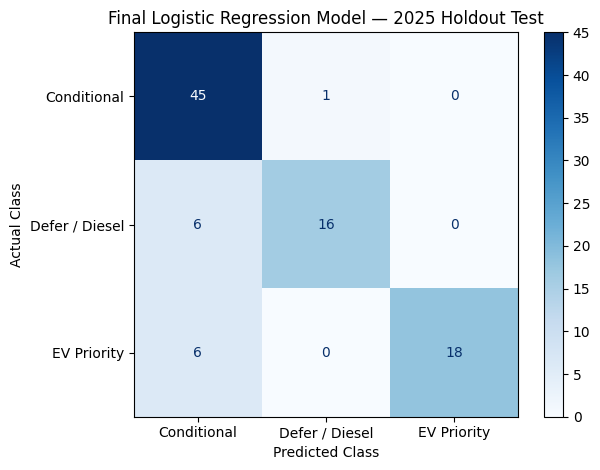

In [70]:
# ============================================================
# FINAL MODEL — CONFUSION MATRIX VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=test_model.classes_,
    display_labels=test_model.classes_,
    cmap="Blues",
    values_format="d"
)

plt.title("Final Logistic Regression Model — 2025 Holdout Test")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# FINAL MODEL — PREDICTION PROBABILITY CHECK
# ============================================================

# Predicted probabilities for the 2025 holdout set
test_probabilities = test_model.predict_proba(X_test)

probability_df = pd.DataFrame(
    test_probabilities,
    columns=[
        f"Probability_{c}"
        for c in test_model.classes_
    ]
)

# Add actual and predicted classes
probability_df["Actual_Class"] = y_test.values
probability_df["Predicted_Class"] = y_pred

print("PREDICTION PROBABILITY CHECK")
print("============================")

print("\nAverage predicted probabilities:")
print(
    probability_df[
        [
            "Probability_Conditional",
            "Probability_Defer / Diesel",
            "Probability_EV Priority"
        ]
    ].mean().round(4)
)

print("\nHighest EV Priority probabilities:")
print(
    probability_df[
        [
            "Probability_EV Priority",
            "Actual_Class",
            "Predicted_Class"
        ]
    ]
    .sort_values(
        "Probability_EV Priority",
        ascending=False
    )
    .head(10)
    .round(4)
)

PREDICTION PROBABILITY CHECK

Average predicted probabilities:
Probability_Conditional       0.5453
Probability_Defer / Diesel    0.1990
Probability_EV Priority       0.2557
dtype: float64

Highest EV Priority probabilities:
    Probability_EV Priority Actual_Class Predicted_Class
23                   0.9907  EV Priority     EV Priority
31                   0.9755  EV Priority     EV Priority
36                   0.9347  EV Priority     EV Priority
25                   0.8792  EV Priority     EV Priority
21                   0.8721  EV Priority     EV Priority
62                   0.7985  EV Priority     EV Priority
74                   0.7861  EV Priority     EV Priority
55                   0.7811  EV Priority     EV Priority
1                    0.7613  EV Priority     EV Priority
15                   0.7265  EV Priority     EV Priority


In [72]:
# ============================================================
# FINAL OPTIMIZATION FEASIBILITY CHECK
# ============================================================

print("FINAL OPTIMIZATION FEASIBILITY CHECK")
print("====================================")

# 1. Budget
budget_ok = (
    opt["EV_Investment_INR"].sum()
    <= OPTIMIZATION_BUDGET_INR
)

# 2. Total EV limit
ev_limit_ok = (
    opt["Optimized_EV_Buses"].sum()
    <= maximum_evs_to_allocate
)

# 3. Depot transition cap
depot_cap_ok = (
    opt["Optimized_EV_Buses"]
    <= opt["Max_EV_Allocation"]
).all()

# 4. Defer/Diesel receives no EV
defer_ok = (
    opt.loc[
        opt["Predicted_2026_Priority"] == "Defer / Diesel",
        "Optimized_EV_Buses"
    ].sum()
    == 0
)

checks = {
    "Budget constraint": budget_ok,
    "Total EV limit": ev_limit_ok,
    "Depot 25% cap": depot_cap_ok,
    "Defer/Diesel exclusion": defer_ok
}

for check, status in checks.items():
    print(
        f"{check:<28}: "
        f"{'PASS ✓' if status else 'FAIL ✗'}"
    )

print("\nOVERALL STATUS")

if all(checks.values()):
    print("✓ ALL OPTIMIZATION CONSTRAINTS PASSED")
    print("✓ FINAL PLAN IS FEASIBLE")
else:
    print("✗ CHECK FAILED — DO NOT FINALIZE")

FINAL OPTIMIZATION FEASIBILITY CHECK
Budget constraint           : PASS ✓
Total EV limit              : PASS ✓
Depot 25% cap               : PASS ✓
Defer/Diesel exclusion      : PASS ✓

OVERALL STATUS
✓ ALL OPTIMIZATION CONSTRAINTS PASSED
✓ FINAL PLAN IS FEASIBLE


In [76]:
# ============================================================
# FINAL MODEL — NEW USER INPUT / FUTURE PREDICTION TEST
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Example of NEW depot conditions entered by a user
# ------------------------------------------------------------

new_depot = pd.DataFrame([{
    "Effective KM": 125000,
    "Passengers": 1850000,
    "Buses Allocated": 80,
    "Schedules Allocated": 65,
    "Estimated CO2 (Tonnes)": 820,
    "Estimated EV Energy (MWh)": 156.25,
    "Potential EV OPEX Saving (INR)": 30000000,
    "Terrain_Score": 0.90
}])

# Make sure feature order is EXACTLY the same as training
new_depot = new_depot[feature_cols]

# ------------------------------------------------------------
# Predict class
# ------------------------------------------------------------

predicted_class = final_model.predict(new_depot)[0]

# ------------------------------------------------------------
# Predict probabilities
# ------------------------------------------------------------

probabilities = final_model.predict_proba(new_depot)[0]

probability_table = pd.DataFrame({
    "Class": final_model.classes_,
    "Probability": probabilities
})

# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("NEW USER INPUT TEST")
print("===================")

print("\nInput:")
print(new_depot.to_string(index=False))

print("\nPrediction:")
print("Predicted Priority :", predicted_class)

print("\nClass Probabilities:")
print(
    probability_table
    .sort_values("Probability", ascending=False)
    .to_string(index=False)
)

print("\n✓ MODEL ACCEPTED NEW INPUT")
print("✓ FUTURE PRIORITY PREDICTION GENERATED")

NEW USER INPUT TEST

Input:
 Effective KM  Passengers  Buses Allocated  Schedules Allocated  Estimated CO2 (Tonnes)  Estimated EV Energy (MWh)  Potential EV OPEX Saving (INR)  Terrain_Score
       125000     1850000               80                   65                     820                     156.25                        30000000            0.9

Prediction:
Predicted Priority : EV Priority

Class Probabilities:
         Class  Probability
   EV Priority     0.764257
   Conditional     0.221637
Defer / Diesel     0.014106

✓ MODEL ACCEPTED NEW INPUT
✓ FUTURE PRIORITY PREDICTION GENERATED


In [77]:
# ============================================================
# TRIVANDRUM CENTRAL — MODEL SANITY CHECK
# ============================================================

trivandrum = opt[
    opt["Depot Name"].str.upper().str.contains("TRIVANDRUM")
].copy()

if len(trivandrum) == 0:
    trivandrum = opt[
        opt["Depot ID"] == "KSRTC-082"
    ].copy()

print("TRIVANDRUM CENTRAL — FINAL ANALYSIS")
print("===================================")

cols = [
    "Depot ID",
    "Depot Name",
    "Buses Allocated",
    "Effective KM",
    "Passengers",
    "Schedules Allocated",
    "Potential EV OPEX Saving (INR)",
    "Estimated CO2 (Tonnes)",
    "Terrain_Score",
    "Predicted_2026_Priority",
    "ML_Suitability_Score",
    "Transition_Priority_Score",
    "Optimized_EV_Buses"
]

available_cols = [c for c in cols if c in trivandrum.columns]

print(
    trivandrum[available_cols]
    .to_string(index=False)
)

TRIVANDRUM CENTRAL — FINAL ANALYSIS
 Depot ID           Depot Name  Buses Allocated  Effective KM  Passengers  Schedules Allocated  Potential EV OPEX Saving (INR)  Estimated CO2 (Tonnes)  Terrain_Score Predicted_2026_Priority  ML_Suitability_Score  Transition_Priority_Score  Optimized_EV_Buses
KSRTC-082 TRIVANDRUM - CENTRAL        64.166667       5328221     7233360            82.583333                       127877304             3499.481015            0.9             Conditional              0.388037                   0.502378                   0
KSRTC-083    TRIVANDRUM - CITY        47.500000       3948767     5360676            61.166667                        94770408             2593.480103            0.9             Conditional              0.056085                   0.309233                   0


In [78]:
# ============================================================
# TRIVANDRUM — SCORE COMPONENT CHECK
# ============================================================

tv = opt[
    opt["Depot ID"].isin(["KSRTC-082", "KSRTC-083"])
].copy()

score_cols = [
    "Depot ID",
    "Depot Name",
    "ML_Suitability_Score",
    "Transition_Priority_Score",
    "Predicted_2026_Priority",
    "Potential EV OPEX Saving (INR)",
    "Estimated CO2 (Tonnes)",
    "Terrain_Score"
]

print(tv[score_cols].to_string(index=False))

 Depot ID           Depot Name  ML_Suitability_Score  Transition_Priority_Score Predicted_2026_Priority  Potential EV OPEX Saving (INR)  Estimated CO2 (Tonnes)  Terrain_Score
KSRTC-082 TRIVANDRUM - CENTRAL              0.388037                   0.502378             Conditional                       127877304             3499.481015            0.9
KSRTC-083    TRIVANDRUM - CITY              0.056085                   0.309233             Conditional                        94770408             2593.480103            0.9


In [80]:
from IPython.display import display

depot_check = opt[[
    "Depot ID",
    "Depot Name",
    "Buses Allocated",
    "Effective KM",
    "Passengers",
    "Potential EV OPEX Saving (INR)",
    "Estimated CO2 (Tonnes)",
    "Terrain_Score",
    "ML_Suitability_Score",
    "Predicted_2026_Priority",
    "Transition_Priority_Score"
]].copy()

depot_check = depot_check.sort_values(
    "Transition_Priority_Score",
    ascending=False
).reset_index(drop=True)

depot_check.index = depot_check.index + 1
depot_check.insert(0, "Rank", depot_check.index)

# Show ALL 92 depots
display(depot_check)

print("\nTotal Depots:", len(depot_check))

,Rank,Depot ID,Depot Name,Buses Allocated,Effective KM,Passengers,Potential EV OPEX Saving (INR),Estimated CO2 (Tonnes),Terrain_Score,ML_Suitability_Score,Predicted_2026_Priority,Transition_Priority_Score
1,1,KSRTC-024,KANNUR,94.416667,7837632,10640031,188103168,5147.617635,0.90,9.971570e-01,EV Priority,0.879520
2,2,KSRTC-032,KOLLAM,89.833333,7465082,10134271,179161968,4902.933405,0.90,9.930935e-01,EV Priority,0.871724
3,3,KSRTC-026,KASARGODE,75.416667,6274632,8518169,150591168,4121.066967,0.90,9.413568e-01,EV Priority,0.801941
4,4,KSRTC-022,KANGANGAD,75.583333,6284264,8531243,150822336,4127.393094,0.90,9.432254e-01,EV Priority,0.794142
5,5,KSRTC-037,KOTTAYAM,81.083333,6725522,9130277,161412528,4417.203519,0.75,9.224971e-01,EV Priority,0.763042
...,...,...,...,...,...,...,...,...,...,...,...,...
88,88,KSRTC-049,MUNNAR,31.916667,2650459,3598149,63611016,1740.774444,0.20,9.806213e-09,Defer / Diesel,0.131155
89,89,KSRTC-079,THODUPUZHA,31.750000,2635743,3578169,63257832,1731.109237,0.20,9.179907e-09,Defer / Diesel,0.125881
90,90,KSRTC-012,CHERUTHONI,31.583333,2619211,3555727,62861064,1720.251312,0.20,8.695860e-09,Defer / Diesel,0.111146
91,91,KSRTC-058,PANDALAM,28.833333,2379622,3230469,57110928,1562.893508,0.75,5.296625e-04,Defer / Diesel,0.088429



Total Depots: 92


In [82]:
print("OPT COLUMNS:")
for i, col in enumerate(opt.columns):
    print(i, repr(col))

OPT COLUMNS:
0 'Depot ID'
1 'Effective KM'
2 'Passengers'
3 'Buses Allocated'
4 'Schedules Allocated'
5 'Estimated CO2 (Tonnes)'
6 'Estimated EV Energy (MWh)'
7 'Potential EV OPEX Saving (INR)'
8 'Terrain_Score'
9 'Predicted_2026_Priority'
10 'Probability_Conditional'
11 'Probability_Defer_Diesel'
12 'Probability_EV Priority'
13 'Depot Name'
14 'District'
15 'Prediction_Confidence'
16 'OPEX_Saving_Score'
17 'CO2_Reduction_Per_Bus'
18 'CO2_Reduction_Score'
19 'ML_Suitability_Score'
20 'Terrain_Suitability_Score'
21 'Transition_Priority_Score'
22 'Transition_Rank'
23 'Final_Transition_Category'
24 'Max_EV_Buses'
25 'OPEX_Saving_Per_Bus'
26 'Allocation_Benefit_Score'
27 'Eligible_for_EV'
28 'Max_EV_Allocation'
29 'Benefit_Per_EV'
30 'Optimized_EV_Buses'
31 'Diesel_Buses_After_Transition'
32 'EV_Investment_INR'
33 'Expected_Annual_OPEX_Saving_INR'
34 'Expected_Annual_CO2_Reduction_Tonnes'


In [83]:
from IPython.display import display

final_depot_view = opt[[
    "Depot ID",
    "Depot Name",
    "District",
    "Buses Allocated",
    "Schedules Allocated",
    "Effective KM",
    "Passengers",
    "Estimated CO2 (Tonnes)",
    "Estimated EV Energy (MWh)",
    "Potential EV OPEX Saving (INR)",
    "Terrain_Score",

    # ML results
    "Predicted_2026_Priority",
    "Probability_EV Priority",
    "Prediction_Confidence",
    "ML_Suitability_Score",

    # Final ranking
    "OPEX_Saving_Score",
    "CO2_Reduction_Per_Bus",
    "CO2_Reduction_Score",
    "Terrain_Suitability_Score",
    "Transition_Priority_Score",
    "Transition_Rank",
    "Final_Transition_Category",

    # Optimization / impact
    "Optimized_EV_Buses",
    "Diesel_Buses_After_Transition",
    "EV_Investment_INR",
    "Expected_Annual_OPEX_Saving_INR",
    "Expected_Annual_CO2_Reduction_Tonnes"
]].sort_values(
    "Transition_Rank"
).reset_index(drop=True)

display(final_depot_view)

print("\nTOTAL DEPOTS:", len(final_depot_view))
print("TOTAL EV BUSES:", final_depot_view["Optimized_EV_Buses"].sum())
print(
    "TOTAL INVESTMENT: ₹{:,.0f}".format(
        final_depot_view["EV_Investment_INR"].sum()
    )
)
print(
    "TOTAL ANNUAL OPEX SAVING: ₹{:,.0f}".format(
        final_depot_view["Expected_Annual_OPEX_Saving_INR"].sum()
    )
)
print(
    "TOTAL ANNUAL CO₂ REDUCTION: {:,.2f} tonnes".format(
        final_depot_view["Expected_Annual_CO2_Reduction_Tonnes"].sum()
    )
)

,Depot ID,Depot Name,District,Buses Allocated,Schedules Allocated,Effective KM,Passengers,Estimated CO2 (Tonnes),Estimated EV Energy (MWh),Potential EV OPEX Saving (INR),...,CO2_Reduction_Score,Terrain_Suitability_Score,Transition_Priority_Score,Transition_Rank,Final_Transition_Category,Optimized_EV_Buses,Diesel_Buses_After_Transition,EV_Investment_INR,Expected_Annual_OPEX_Saving_INR,Expected_Annual_CO2_Reduction_Tonnes
0,KSRTC-024,KANNUR,Kannur,94.416667,85.666667,7837632,10640031,5147.617635,9797,188103168,...,0.453285,0.90,0.879520,1,High Priority,23,71,276000000,4.582213e+07,1253.965108
1,KSRTC-032,KOLLAM,Kollam,89.833333,84.083333,7465082,10134271,4902.933405,9330,179161968,...,0.524667,0.90,0.871724,2,High Priority,22,68,264000000,4.387640e+07,1200.718385
2,KSRTC-026,KASARGODE,Kasaragod,75.416667,68.166667,6274632,8518169,4121.066967,7845,150591168,...,0.605898,0.90,0.801941,3,High Priority,18,57,216000000,3.594220e+07,983.591674
3,KSRTC-022,KANGANGAD,Kasaragod,75.583333,68.166667,6284264,8531243,4127.393094,7857,150822336,...,0.560523,0.90,0.794142,4,High Priority,19,57,228000000,3.791344e+07,1037.536522
4,KSRTC-037,KOTTAYAM,Kottayam,81.083333,71.333333,6725522,9130277,4417.203519,8407,161412528,...,0.400393,0.75,0.763042,5,High Priority,18,63,216000000,3.583259e+07,980.591943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,KSRTC-049,MUNNAR,Idukki,31.916667,28.333333,2650459,3598149,1740.774444,3313,63611016,...,0.479198,0.20,0.131155,88,Low Priority,0,32,0,0.000000e+00,0.000000
88,KSRTC-079,THODUPUZHA,Idukki,31.750000,27.916667,2635743,3578169,1731.109237,3295,63257832,...,0.456865,0.20,0.125881,89,Low Priority,0,32,0,0.000000e+00,0.000000
89,KSRTC-012,CHERUTHONI,Idukki,31.583333,27.666667,2619211,3555727,1720.251312,3274,62861064,...,0.387728,0.20,0.111146,90,Low Priority,0,32,0,0.000000e+00,0.000000
90,KSRTC-058,PANDALAM,Pathanamthitta,28.833333,26.583333,2379622,3230469,1562.893508,2975,57110928,...,0.063829,0.75,0.088429,91,Low Priority,0,29,0,0.000000e+00,0.000000



TOTAL DEPOTS: 92
TOTAL EV BUSES: 100
TOTAL INVESTMENT: ₹1,200,000,000
TOTAL ANNUAL OPEX SAVING: ₹199,386,761
TOTAL ANNUAL CO₂ REDUCTION: 5,456.40 tonnes


In [84]:
ml_results = opt[[
    "Depot ID",
    "Depot Name",
    "District",
    "Predicted_2026_Priority",
    "Probability_EV Priority",
    "Probability_Conditional",
    "Probability_Defer_Diesel",
    "Prediction_Confidence",
    "ML_Suitability_Score"
]].sort_values(
    "Probability_EV Priority",
    ascending=False
).reset_index(drop=True)

display(ml_results)

print("Total depots:", len(ml_results))

,Depot ID,Depot Name,District,Predicted_2026_Priority,Probability_EV Priority,Probability_Conditional,Probability_Defer_Diesel,Prediction_Confidence,ML_Suitability_Score
0,KSRTC-024,KANNUR,Kannur,EV Priority,9.971570e-01,0.002842,0.000001,0.997157,9.971570e-01
1,KSRTC-032,KOLLAM,Kollam,EV Priority,9.930935e-01,0.006903,0.000004,0.993094,9.930935e-01
2,KSRTC-022,KANGANGAD,Kasaragod,EV Priority,9.432254e-01,0.056566,0.000209,0.943225,9.432254e-01
3,KSRTC-026,KASARGODE,Kasaragod,EV Priority,9.413568e-01,0.058429,0.000215,0.941357,9.413568e-01
4,KSRTC-037,KOTTAYAM,Kottayam,EV Priority,9.224971e-01,0.076071,0.001432,0.922497,9.224971e-01
...,...,...,...,...,...,...,...,...,...
87,KSRTC-028,KATTAPPANA,Idukki,Defer / Diesel,9.079102e-09,0.000315,0.999685,0.999685,9.079102e-09
88,KSRTC-040,KUMILY,Idukki,Defer / Diesel,8.975987e-09,0.000322,0.999678,0.999678,8.975987e-09
89,KSRTC-047,MOOLAMATTOM,Idukki,Defer / Diesel,8.739898e-09,0.000315,0.999685,0.999685,8.739898e-09
90,KSRTC-051,NEDUMKANDAM,Idukki,Defer / Diesel,8.700465e-09,0.000315,0.999685,0.999685,8.700465e-09


Total depots: 92
